Device: cuda
Training samples: 20
Pre-uploading dataset tensors to GPU ...


Images: 100%|██████████| 20/20 [38:00<00:00, 114.02s/it]



=== MISSING DATA (NaN count per model) ===
SIREN Dice: 0 missing
ReLU Dice: 0 missing
Occupancy Dice: 0 missing

SIREN HD95: 0 missing
ReLU HD95: 0 missing
Occupancy HD95: 0 missing

SIREN ASD: 0 missing
ReLU ASD: 0 missing
Occupancy ASD: 0 missing

SIREN EulerCharErr: 0 missing
ReLU EulerCharErr: 0 missing
Occupancy EulerCharErr: 0 missing

SIREN GradErr: 0 missing
ReLU GradErr: 0 missing
Occupancy GradErr: 20 missing

SIREN GradErrAutograd: 0 missing
ReLU GradErrAutograd: 0 missing
Occupancy GradErrAutograd: 20 missing

SIREN WidthErr: 0 missing
ReLU WidthErr: 0 missing
Occupancy WidthErr: 0 missing

SIREN CurvErr: 0 missing
ReLU CurvErr: 0 missing
Occupancy CurvErr: 20 missing

SIREN CoordSens: 0 missing
ReLU CoordSens: 0 missing
Occupancy CoordSens: 0 missing

SIREN ParticipationRatio: 0 missing
ReLU ParticipationRatio: 0 missing
Occupancy ParticipationRatio: 0 missing

SIREN EffectiveRank: 0 missing
ReLU EffectiveRank: 0 missing
Occupancy EffectiveRank: 0 missing

SIREN SpectralE

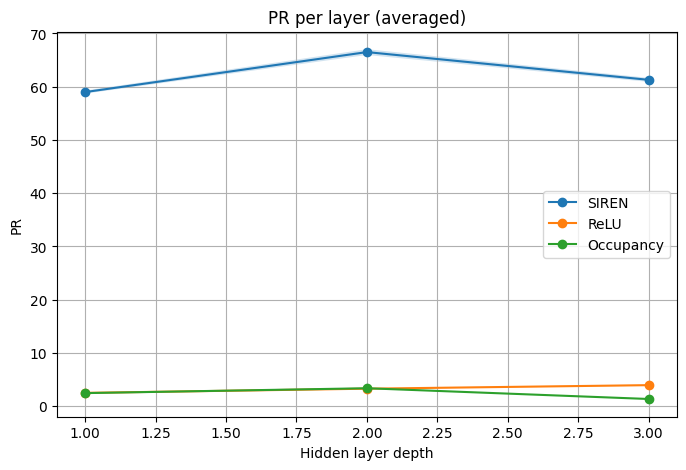

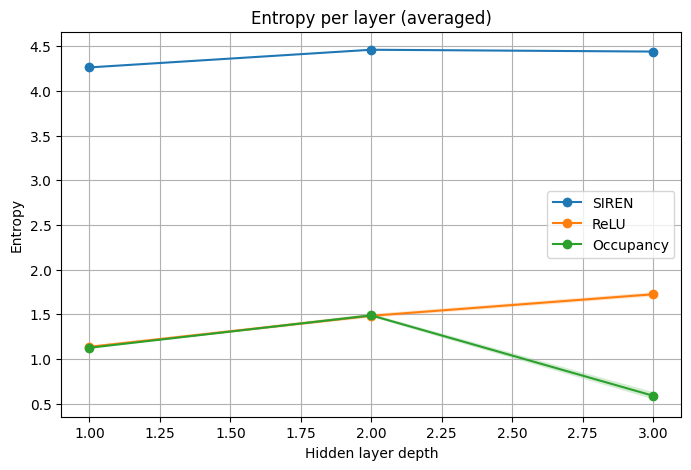

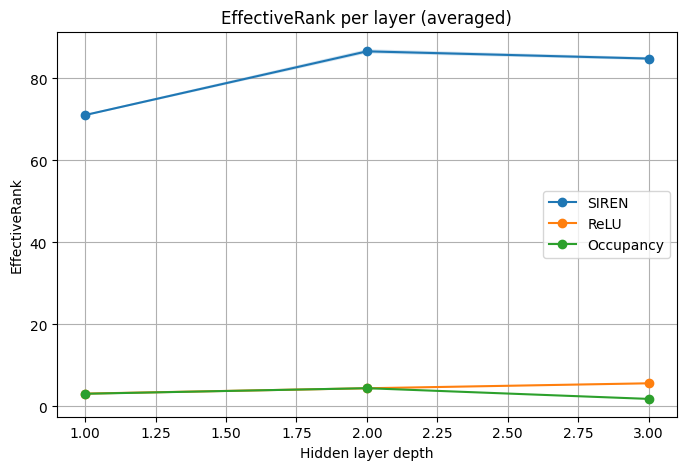

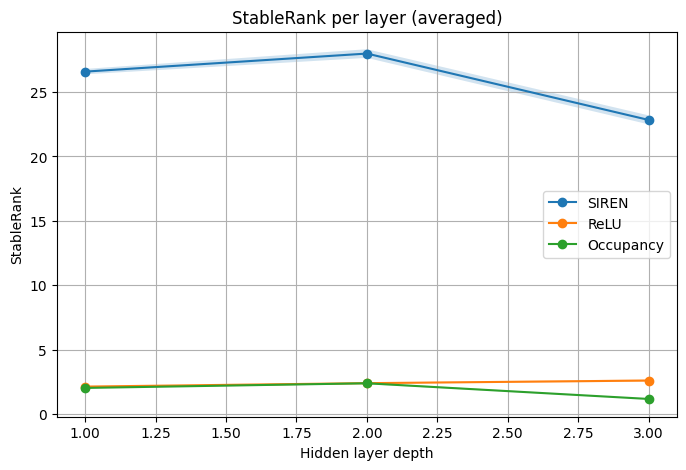

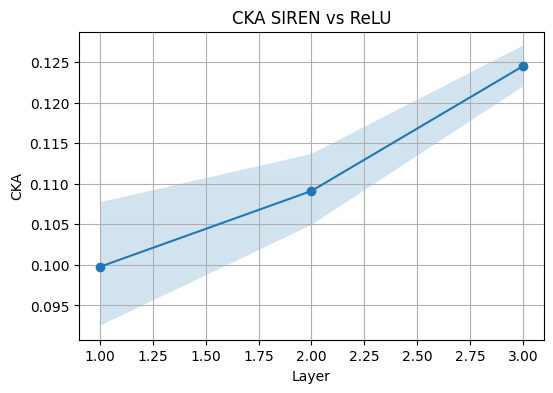

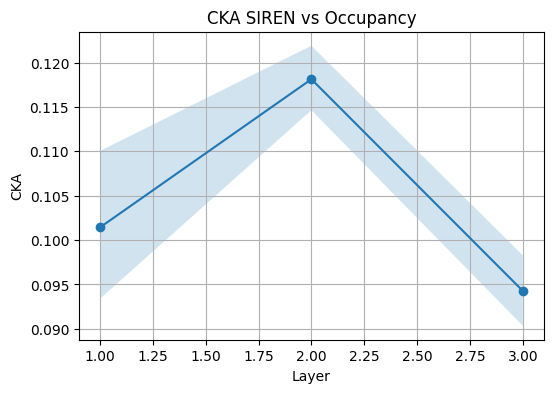

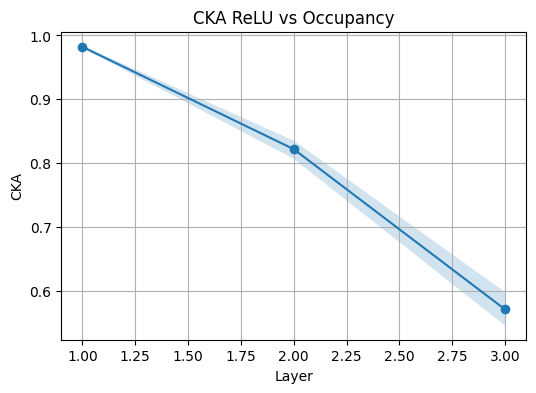

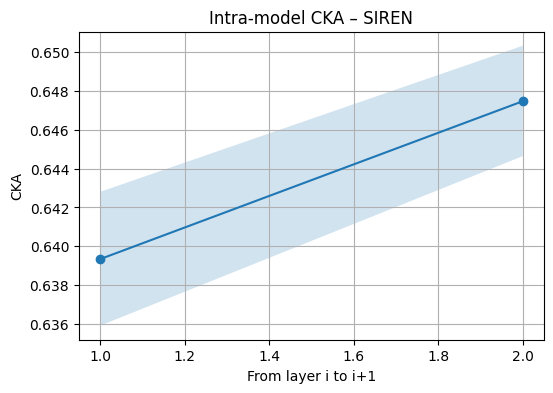

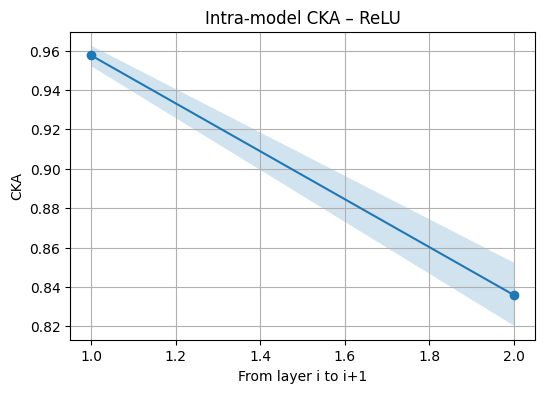

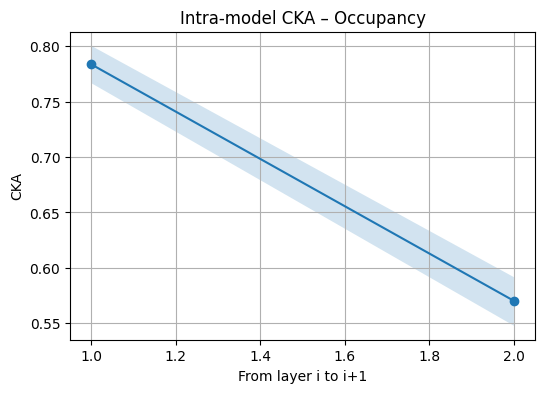

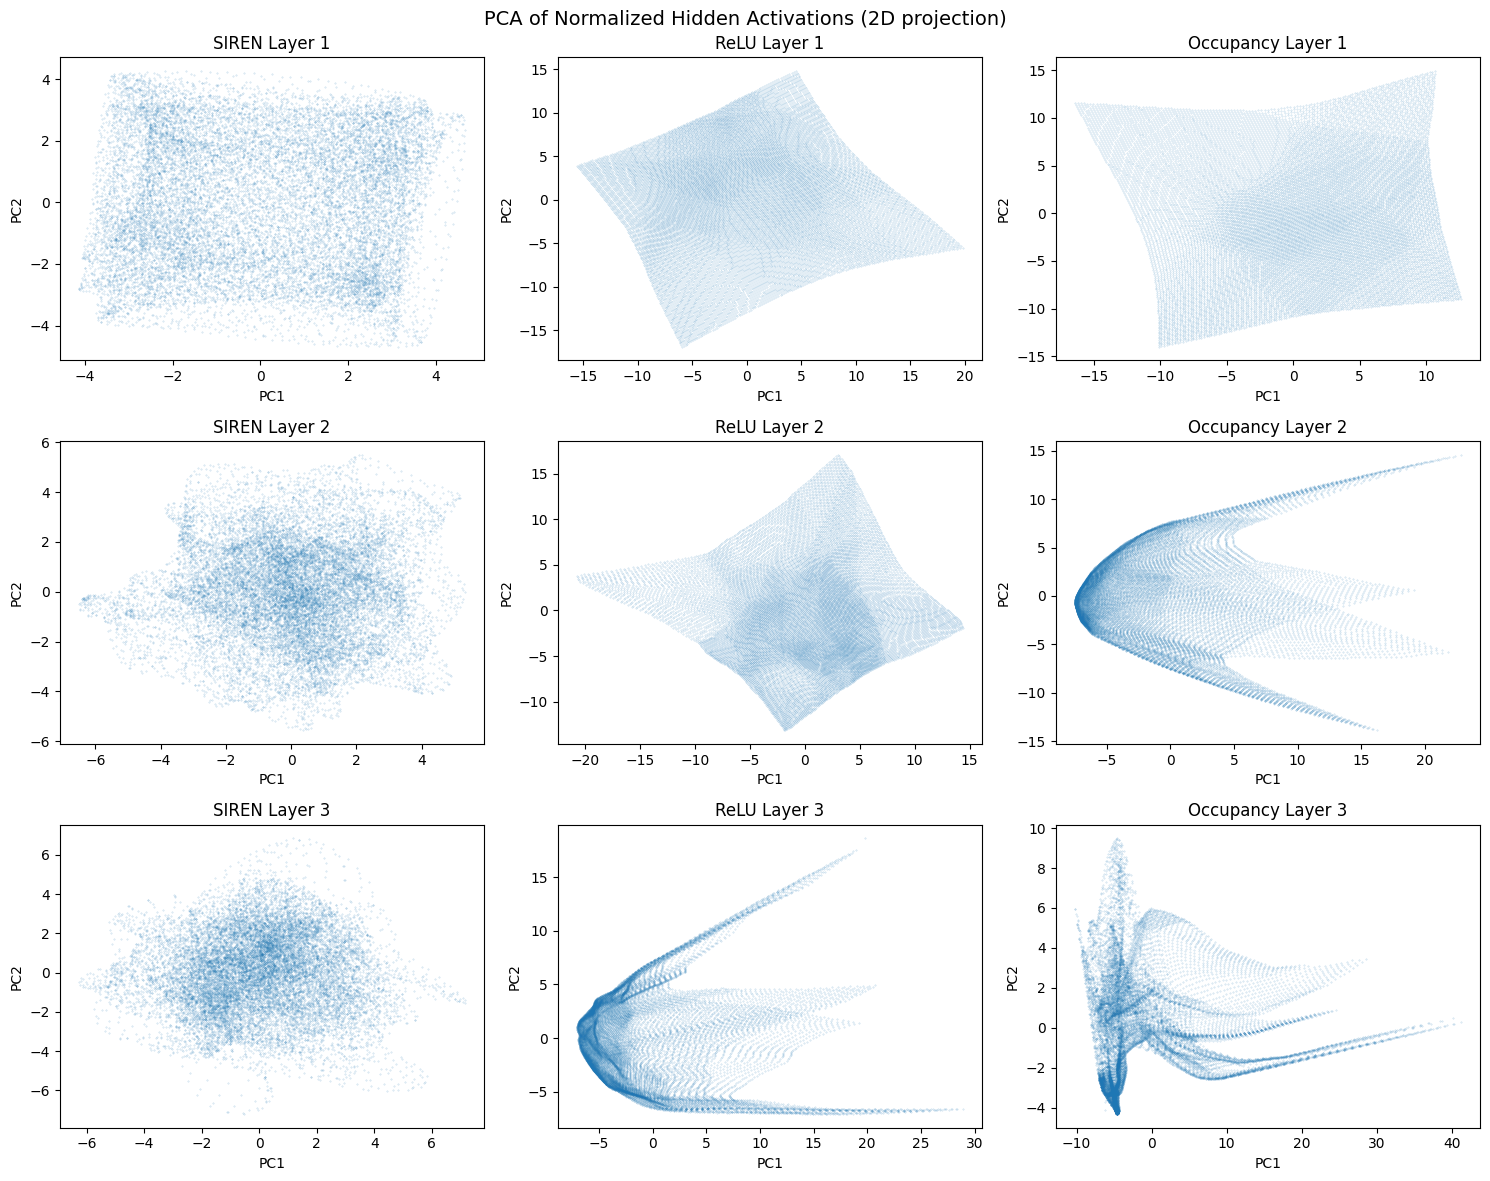

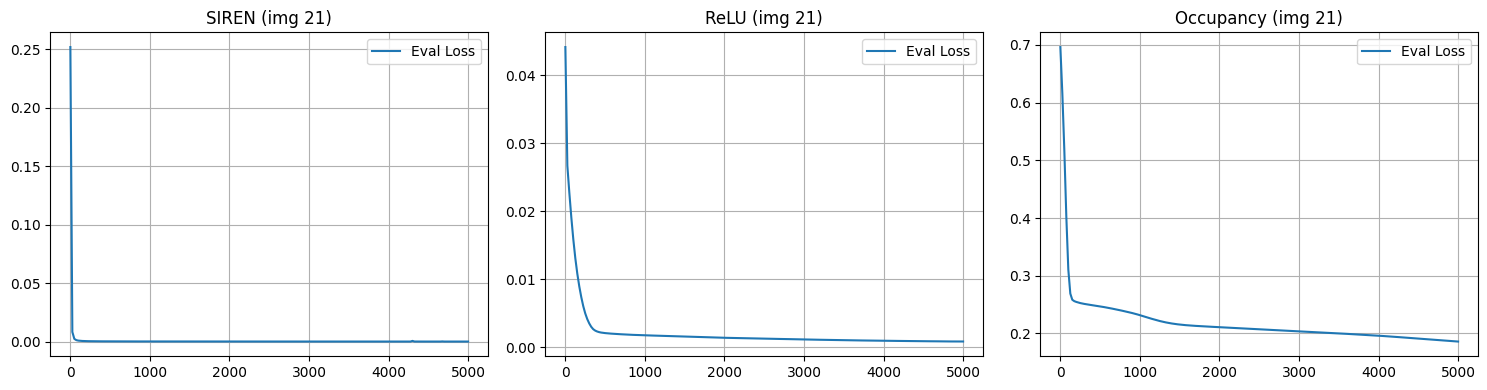

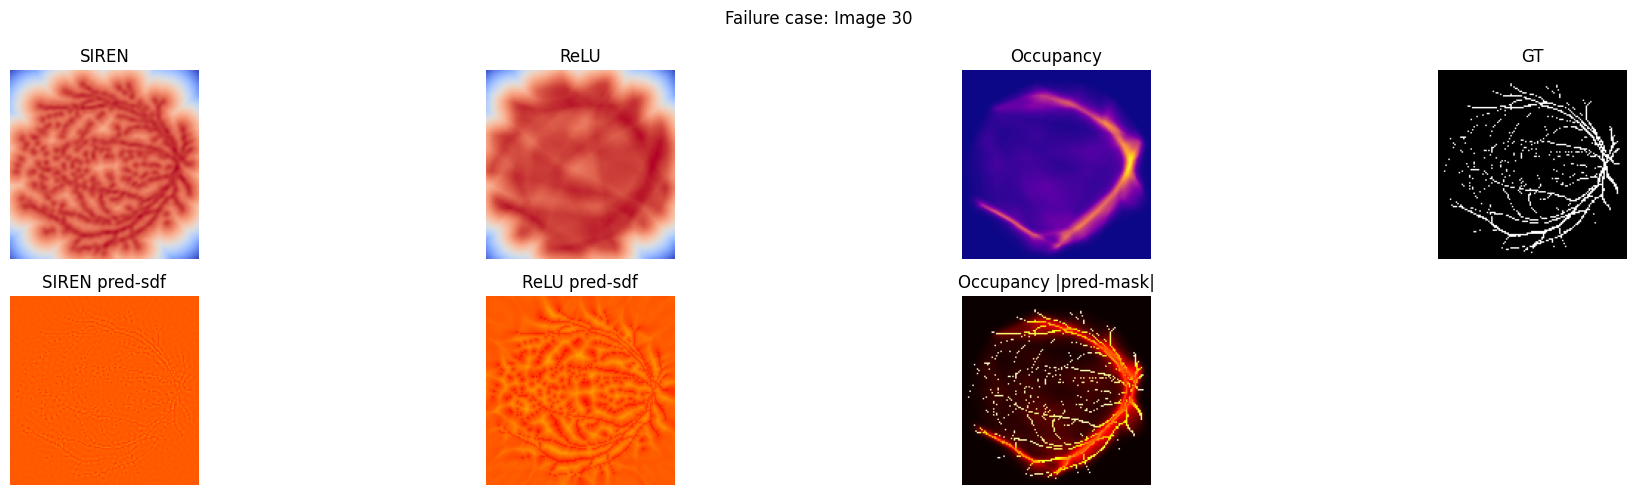

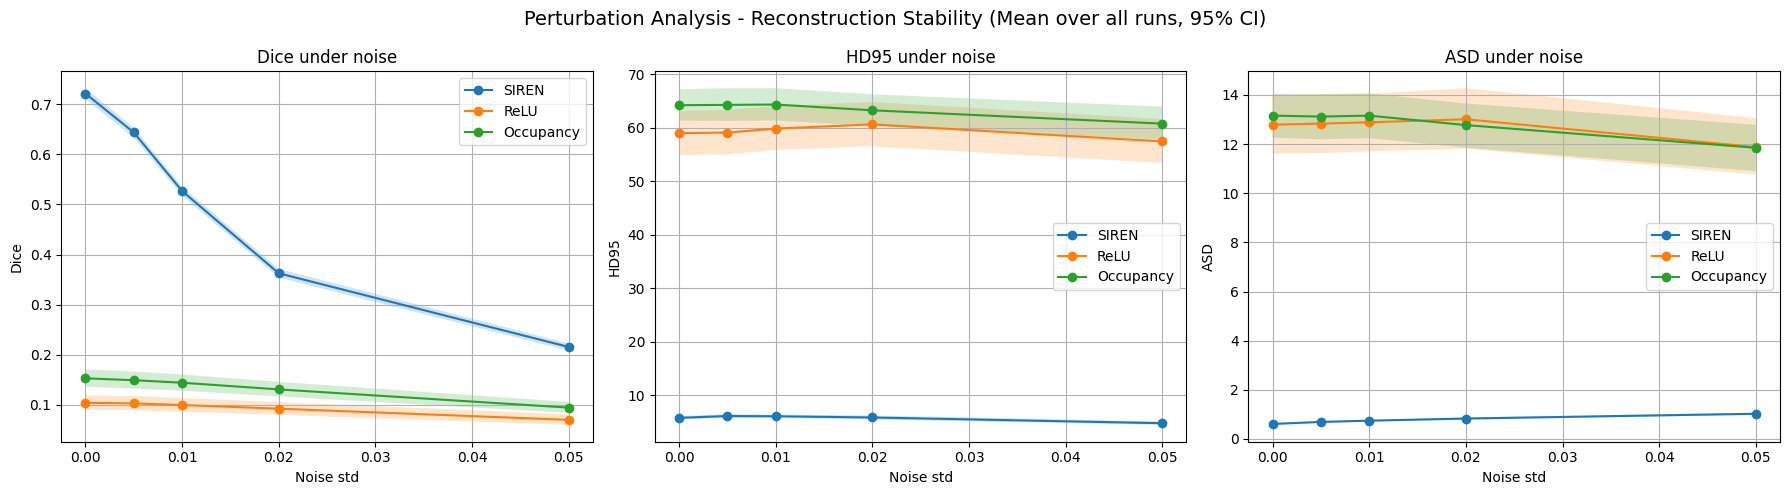

In [1]:
# == Beyond Reconstruction (DRIVE) ==

!pip install -q torch torchvision matplotlib numpy scipy scikit-image opencv-python-headless tqdm scikit-learn statsmodels

import os, math, warnings, time, hashlib, copy
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt, map_coordinates, gaussian_filter
from scipy.spatial import KDTree
from skimage import measure
from skimage.morphology import skeletonize, remove_small_objects
from skimage.segmentation import find_boundaries
from scipy.stats import wilcoxon, spearmanr
import torch, torch.nn as nn
from torch.optim import Adam
from PIL import Image
import cv2
from itertools import combinations
from statsmodels.stats.multitest import multipletests
import pandas as pd
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

RUN_SYNTHETIC_TEST = False

def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")

    if device.type == 'cuda':
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32 = False
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    BASE_SEEDS = [42, 123, 999]
    NOISE_LEVELS = [0.0, 0.005, 0.01, 0.02, 0.05]

    DATA_ROOT = '/kaggle/input/datasets/andrewmvd/drive-digital-retinal-images-for-vessel-extraction/DRIVE'

    # --- Data loading -----
    def load_drive_data():
        train_img_dir = os.path.join(DATA_ROOT, 'training', 'images')
        train_man_dir = os.path.join(DATA_ROOT, 'training', '1st_manual')
        data = []
        for f in sorted(os.listdir(train_img_dir)):
            if f.endswith('.tif'):
                num = f.split('_')[0]
                man_path = os.path.join(train_man_dir, f"{num}_manual1.gif")
                if os.path.exists(man_path):
                    data.append({'image': os.path.join(train_img_dir, f),
                                 'manual': man_path, 'id': num})
        return data

    train_data = load_drive_data()
    print(f"Training samples: {len(train_data)}")

    COORD_GRID_CACHE = {}
    def coord_grid(shape):
        if shape in COORD_GRID_CACHE:
            return COORD_GRID_CACHE[shape]
        h, w = shape
        x = np.linspace(-1, 1, w)
        y = np.linspace(-1, 1, h)
        xx, yy = np.meshgrid(x, y)
        grid = np.stack([xx, yy], axis=-1).reshape(-1, 2).astype(np.float32)
        COORD_GRID_CACHE[shape] = grid
        return grid

    shared_coords_np = coord_grid((128, 128))
    shared_coords_gpu = torch.from_numpy(shared_coords_np).to(device)

    def compute_sdf(mask):
        mask_bin = (mask > 0.5).astype(np.uint8)
        dist_in = distance_transform_edt(mask_bin)
        dist_out = distance_transform_edt(1 - mask_bin)
        sdf = dist_in - dist_out
        max_dist = max(dist_in.max(), dist_out.max())
        if max_dist > 0:
            sdf /= max_dist
        else:
            warnings.warn("Empty or full mask detected; SDF set to zeros.")
        return sdf.astype(np.float32)

    def load_sample(item):
        img = np.array(Image.open(item['image']))
        if img.ndim == 3:
            img = img[:,:,0]
        img = img.astype(np.float32)/255.0
        manual = np.array(Image.open(item['manual']))
        manual = (manual > 128).astype(np.float32)
        return img, manual

    def preprocess(img, manual, size=(128,128)):
        img = cv2.resize(img, size, interpolation=cv2.INTER_LINEAR)
        manual = cv2.resize(manual, size, interpolation=cv2.INTER_NEAREST)
        manual = (manual > 0.5).astype(np.float32)
        sdf = compute_sdf(manual)
        return img, manual, sdf

    gpu_data = {}
    print("Pre-uploading dataset tensors to GPU ...")
    for item in tqdm(train_data, desc="Uploading"):
        img, manual = load_sample(item)
        _, mask_p, sdf_gt = preprocess(img, manual, size=(128,128))
        sdf_gpu = torch.from_numpy(sdf_gt.flatten()).view(-1,1).to(device)
        mask_gpu = torch.from_numpy(mask_p.flatten()).view(-1,1).to(device)
        gpu_data[item['id']] = (sdf_gpu, mask_gpu)

    # ---- Networks ------
    class SineLayer(nn.Module):
        def __init__(self, in_f, out_f, is_first=False, omega0=30.0):
            super().__init__()
            self.omega0 = omega0
            self.linear = nn.Linear(in_f, out_f)
            with torch.no_grad():
                if is_first:
                    self.linear.weight.uniform_(-1/in_f, 1/in_f)
                else:
                    self.linear.weight.uniform_(-math.sqrt(6/in_f)/omega0,
                                                math.sqrt(6/in_f)/omega0)
        def forward(self, x):
            return torch.sin(self.omega0 * self.linear(x))

    class SIREN_SDF(nn.Module):
        def __init__(self, in_dim=2, hidden=128, layers=4, omega0=30.0):
            super().__init__()
            self.layers = nn.ModuleList()
            self.layers.append(SineLayer(in_dim, hidden, is_first=True, omega0=omega0))
            for _ in range(layers-2):
                self.layers.append(SineLayer(hidden, hidden, omega0=omega0))
            self.final = nn.Linear(hidden, 1)

        def forward(self, x, return_all_hidden=False):
            h = x
            hidden_list = []
            for layer in self.layers:
                h = layer(h)
                if return_all_hidden:
                    hidden_list.append(h)
            out = self.final(h)
            if return_all_hidden:
                return out, hidden_list
            return out

    class ReLU_SDF(nn.Module):
        def __init__(self, in_dim=2, hidden=128, layers=4):
            super().__init__()
            blocks = [nn.Linear(in_dim, hidden), nn.ReLU()]
            for _ in range(layers-2):
                blocks += [nn.Linear(hidden, hidden), nn.ReLU()]
            self.blocks = nn.ModuleList(blocks)
            self.final = nn.Linear(hidden, 1)

        def forward(self, x, return_all_hidden=False):
            h = x
            hidden_list = []
            for layer in self.blocks:
                h = layer(h)
                if return_all_hidden and isinstance(layer, nn.ReLU):
                    hidden_list.append(h)
            out = self.final(h)
            if return_all_hidden:
                return out, hidden_list
            return out

    class OccupancyNet(nn.Module):
        def __init__(self, in_dim=2, hidden=128, layers=4):
            super().__init__()
            blocks = [nn.Linear(in_dim, hidden), nn.ReLU()]
            for _ in range(layers-2):
                blocks += [nn.Linear(hidden, hidden), nn.ReLU()]
            self.blocks = nn.ModuleList(blocks)
            self.final = nn.Linear(hidden, 1)

        def forward(self, x, return_all_hidden=False):
            h = x
            hidden_list = []
            for layer in self.blocks:
                h = layer(h)
                if return_all_hidden and isinstance(layer, nn.ReLU):
                    hidden_list.append(h)
            out = self.final(h)
            if return_all_hidden:
                return out, hidden_list
            return out

    @torch.no_grad()
    def compute_hidden_activations_gpu(model, coords_gpu):
        model.eval()
        _, hidden_list = model(coords_gpu, return_all_hidden=True)
        return hidden_list

    def spectral_metrics_from_activations_gpu(H):
        H = H - H.mean(dim=0, keepdim=True)
        cov = H.T @ H / (H.shape[0] - 1)
        eigvals = torch.linalg.eigvalsh(cov)
        eigsum = eigvals.sum()
        if eigsum < 1e-12:
            return 0.0, 0.0, 0.0, 0.0
        pr = (eigsum ** 2) / (torch.sum(eigvals ** 2) + 1e-8)
        p = eigvals / (eigsum + 1e-8)
        p = p[p > 0]
        ent = -torch.sum(p * torch.log(p))
        eff_rank = torch.exp(ent).item()
        stable_rank = eigsum / (eigvals.max() + 1e-8)
        return pr.item(), ent.item(), eff_rank, stable_rank.item()

    def cka_similarity_gpu(H1, H2):
        H1 = H1 - H1.mean(dim=0)
        H2 = H2 - H2.mean(dim=0)
        cross = torch.linalg.norm(H1.T @ H2, 'fro') ** 2
        self1 = torch.linalg.norm(H1.T @ H1, 'fro') ** 2
        self2 = torch.linalg.norm(H2.T @ H2, 'fro') ** 2
        return (cross / (torch.sqrt(self1 * self2) + 1e-8)).item()

    def compute_pairwise_cka_from_acts(precomputed_hidden):
        acts = precomputed_hidden
        num_layers = len(acts[list(acts.keys())[0]])
        cka_results = {}
        for (n1, n2) in combinations(acts.keys(), 2):
            layer_cka = []
            for l in range(num_layers):
                cka = cka_similarity_gpu(acts[n1][l], acts[n2][l])
                layer_cka.append(cka)
            cka_results[(n1, n2)] = layer_cka
        return cka_results

    def compute_intra_cka_from_acts(acts, model_key):
        hidden = acts[model_key]
        num_layers = len(hidden)
        intra = []
        for l in range(num_layers - 1):
            intra.append(cka_similarity_gpu(hidden[l], hidden[l+1]))
        return intra

    def jacobian_sensitivity_gpu(model, coords_gpu):
        model.eval()
        coords = coords_gpu.clone().requires_grad_(True)
        out = model(coords)
        grad = torch.autograd.grad(out, coords,
                                   grad_outputs=torch.ones_like(out),
                                   create_graph=False)[0]
        frob = torch.norm(grad, p='fro', dim=1)
        return frob.mean().item()

    # Training functions
    def train_sdf_gpu(model, coords_gpu, sdf_gpu,
                      epochs=5000, lr=1e-4, patience=500, eval_every=25,
                      return_losses=False):
        model.train()
        opt = Adam(model.parameters(), lr=lr)
        mse = nn.MSELoss()
        best_loss = float('inf')
        patience_cnt = 0
        best_state = None
        best_epoch = 0
        eval_losses, eval_epochs = [], []

        for ep in range(epochs):
            out = model(coords_gpu)
            loss = mse(out, sdf_gpu)
            opt.zero_grad()
            loss.backward()
            opt.step()

            if ep % eval_every == 0 or ep == epochs - 1:
                model.eval()
                with torch.inference_mode():
                    eval_loss = mse(model(coords_gpu), sdf_gpu).item()
                model.train()
                if return_losses:
                    eval_losses.append(eval_loss)
                    eval_epochs.append(ep)
                if eval_loss < best_loss:
                    best_loss = eval_loss
                    patience_cnt = 0
                    best_epoch = ep
                    best_state = copy.deepcopy(model.state_dict())
                else:
                    patience_cnt += 1
                    if patience_cnt >= patience // eval_every:
                        break

        if best_state is not None:
            model.load_state_dict(best_state)
        info = {'best_epoch': best_epoch, 'best_loss': best_loss}
        if return_losses:
            info['eval_losses'] = eval_losses
            info['eval_epochs'] = eval_epochs
        return info

    def train_occ_gpu(model, coords_gpu, mask_gpu,
                      epochs=5000, lr=1e-4, patience=500, eval_every=25,
                      return_losses=False):
        model.train()
        opt = Adam(model.parameters(), lr=lr)
        bce = nn.BCEWithLogitsLoss()
        best_loss = float('inf')
        patience_cnt = 0
        best_state = None
        best_epoch = 0
        eval_losses, eval_epochs = [], []

        for ep in range(epochs):
            logits = model(coords_gpu)
            loss = bce(logits, mask_gpu)
            opt.zero_grad()
            loss.backward()
            opt.step()

            if ep % eval_every == 0 or ep == epochs - 1:
                model.eval()
                with torch.inference_mode():
                    eval_loss = bce(model(coords_gpu), mask_gpu).item()
                model.train()
                if return_losses:
                    eval_losses.append(eval_loss)
                    eval_epochs.append(ep)
                if eval_loss < best_loss:
                    best_loss = eval_loss
                    patience_cnt = 0
                    best_epoch = ep
                    best_state = copy.deepcopy(model.state_dict())
                else:
                    patience_cnt += 1
                    if patience_cnt >= patience // eval_every:
                        break

        if best_state is not None:
            model.load_state_dict(best_state)
        info = {'best_epoch': best_epoch, 'best_loss': best_loss}
        if return_losses:
            info['eval_losses'] = eval_losses
            info['eval_epochs'] = eval_epochs
        return info

    # --- Reconstruction metrics ----
    def dice(pred_bin, gt_bin):
        inter = np.sum(pred_bin * gt_bin)
        return 2*inter / (np.sum(pred_bin) + np.sum(gt_bin) + 1e-8)

    def hausdorff95(pred_bin, gt_bin):
        bound_p = find_boundaries(pred_bin, mode='thick')
        bound_g = find_boundaries(gt_bin, mode='thick')
        pts_p = np.argwhere(bound_p)
        pts_g = np.argwhere(bound_g)
        if len(pts_p)==0 or len(pts_g)==0:
            return np.nan
        tree_p = KDTree(pts_p)
        tree_g = KDTree(pts_g)
        dist_pg = tree_g.query(pts_p)[0]
        dist_gp = tree_p.query(pts_g)[0]
        return max(np.percentile(dist_pg, 95), np.percentile(dist_gp, 95))

    def asd(pred_bin, gt_bin):
        bound_p = find_boundaries(pred_bin, mode='thick')
        bound_g = find_boundaries(gt_bin, mode='thick')
        pts_p = np.argwhere(bound_p)
        pts_g = np.argwhere(bound_g)
        if len(pts_p) == 0 or len(pts_g) == 0:
            return np.nan
        tree_p = KDTree(pts_p)
        tree_g = KDTree(pts_g)
        d_p2g = tree_g.query(pts_p)[0]
        d_g2p = tree_p.query(pts_g)[0]
        return (np.mean(d_p2g) + np.mean(d_g2p)) / 2.0

    def reconstruction_metrics(pred_field, gt_mask, field_type='sdf'):
        th = 0.0 if field_type=='sdf' else 0.5
        pred_bin = (pred_field > th).astype(np.float32)
        gt_bin = (gt_mask > 0.5).astype(np.float32)
        return {'Dice': dice(pred_bin, gt_bin),
                'HD95': hausdorff95(pred_bin, gt_bin),
                'ASD':  asd(pred_bin, gt_bin)}

    # --- Geometry metrics ---
    def _boundary_mask_from_sdf(gt_sdf, eps=0.05, min_pixels=50):
        boundary = np.abs(gt_sdf) < eps
        if boundary.sum() < min_pixels:
            mask = gt_sdf <= 0
            dist = distance_transform_edt(mask) + distance_transform_edt(~mask)
            boundary = dist < 1.5
        if boundary.sum() < 10:
            return None
        return boundary

    def _finite_difference_gradient(f):
        gy = np.gradient(f, axis=0)
        gx = np.gradient(f, axis=1)
        return gx, gy

    def gradient_fidelity(pred_field, gt_sdf, eps=0.05):
        boundary = _boundary_mask_from_sdf(gt_sdf, eps)
        if boundary is None:
            return np.nan
        gp_x, gp_y = _finite_difference_gradient(pred_field)
        gg_x, gg_y = _finite_difference_gradient(gt_sdf)
        np_n = np.sqrt(gp_x**2 + gp_y**2) + 1e-8
        ng_n = np.sqrt(gg_x**2 + gg_y**2) + 1e-8
        cos = (gp_x*gg_x + gp_y*gg_y) / (np_n * ng_n)
        ang = np.arccos(np.clip(cos[boundary], -1, 1))
        return np.mean(ang) * 180/np.pi

    def gradient_fidelity_autograd(model, coords_gpu, gt_sdf, eps=0.05):
        model.eval()
        boundary = _boundary_mask_from_sdf(gt_sdf, eps)
        if boundary is None:
            return np.nan
        coords = coords_gpu.clone().requires_grad_(True)
        out = model(coords)
        grad = torch.autograd.grad(out, coords,
                                   grad_outputs=torch.ones_like(out),
                                   create_graph=False, retain_graph=False)[0]
        if grad is None or torch.isnan(grad).any():
            return np.nan
        pred_grad = grad.detach().cpu().numpy().reshape(gt_sdf.shape[0], gt_sdf.shape[1], 2)
        gg_x, gg_y = _finite_difference_gradient(gt_sdf)
        px = pred_grad[...,0]; py = pred_grad[...,1]
        norm_p = np.sqrt(px**2 + py**2) + 1e-8
        norm_g = np.sqrt(gg_x**2 + gg_y**2) + 1e-8
        cos = (px*gg_x + py*gg_y) / (norm_p * norm_g)
        ang = np.arccos(np.clip(cos[boundary], -1, 1))
        return np.mean(ang) * 180/np.pi

    def _finite_difference_hessian(f):
        """
        Compute second-order central differences.
        Returns (d^2f/dx^2, d^2f/dy^2, d^2f/dxdy).
        """
        dfdy, dfdx = np.gradient(f)
        d2fdx2 = np.gradient(dfdx, axis=1)  
        d2fdy2 = np.gradient(dfdy, axis=0)   
        d2fdxdy = 0.5 * (np.gradient(dfdx, axis=0) + np.gradient(dfdy, axis=1))
        return d2fdx2, d2fdy2, d2fdxdy

    def curvature_fidelity(pred_field, gt_sdf, eps=0.05):
        """
        Mean curvature error of the zero level set, using finite differences.
        The curvature of an implicit surface f(x,y)=0 is
            κ = (f_x^2 f_yy - 2 f_x f_y f_xy + f_y^2 f_xx) / (f_x^2+f_y^2)^(3/2)
        This is applied to both the prediction and the ground truth.
        """
        boundary = _boundary_mask_from_sdf(gt_sdf, eps)
        if boundary is None:
            return np.nan

        # Smooth both fields for numerical stability
        pred_smooth = gaussian_filter(pred_field, sigma=0.5)
        sdf_s = gaussian_filter(gt_sdf, sigma=0.5)

        # Predicted derivatives
        gxx_p, gyy_p, gxy_p = _finite_difference_hessian(pred_smooth)
        fx_p, fy_p = np.gradient(pred_smooth)

        # GT derivatives
        gxx, gyy, gxy = _finite_difference_hessian(sdf_s)
        fx, fy = np.gradient(sdf_s)

        # Mean curvature of GT
        grad_norm2_gt = fx**2 + fy**2 + 1e-8
        mc_gt = (fx**2 * gyy - 2 * fx * fy * gxy + fy**2 * gxx) / (grad_norm2_gt ** 1.5)

        # Mean curvature of prediction (using its own derivatives)
        grad_norm2_p = fx_p**2 + fy_p**2 + 1e-8
        mc_pred = (fx_p**2 * gyy_p - 2 * fx_p * fy_p * gxy_p + fy_p**2 * gxx_p) / (grad_norm2_p ** 1.5)

        mae = np.mean(np.abs(mc_pred[boundary] - mc_gt[boundary]))
        norm_factor = np.mean(np.abs(mc_gt[boundary])) + 1e-3
        return mae / norm_factor

    def euler_characteristic_fidelity(pred_field, gt_binary_mask, field_type='sdf'):
        gt_bin = (gt_binary_mask > 0.5).astype(bool)
        if np.sum(gt_bin) == 0:
            return np.nan
        euler_gt = measure.euler_number(gt_bin, connectivity=2)
        if field_type == 'sdf':
            ths = np.linspace(-0.8, 0.8, 50)
            sigma = 0.15
            weights = np.exp(-((ths - 0.0) ** 2) / (2 * sigma ** 2))
        else:
            ths = np.linspace(0.1, 0.9, 50)
            sigma = 0.15
            weights = np.exp(-((ths - 0.5) ** 2) / (2 * sigma ** 2))
        euler_pred = [measure.euler_number(pred_field > t, connectivity=2) for t in ths]
        errs = np.abs(np.array(euler_pred) - euler_gt)
        return np.average(errs, weights=weights)

    def vessel_width_fidelity(pred_field, gt_sdf, gt_mask, field_type='sdf',
                              max_radius=20, rng_seed=42):
        mask_bin = (gt_mask > 0.5).astype(np.uint8)
        skel = skeletonize(mask_bin)
        skel = remove_small_objects(skel, min_size=4, connectivity=2)
        pts = np.argwhere(skel)
        if len(pts) < 2:
            return np.nan
        rng = np.random.RandomState(rng_seed)
        if 500 < len(pts):
            pts = pts[rng.choice(len(pts), 500, replace=False)]
        level_pred = 0.0 if field_type=='sdf' else 0.5
        level_gt   = 0.0 if field_type=='sdf' else 0.5
        gt_profile = gt_mask if field_type=='occ' else gt_sdf

        errors = []
        for y, x in pts:
            if y < 2 or y >= gt_sdf.shape[0]-2 or x < 2 or x >= gt_sdf.shape[1]-2:
                continue
            dxx = gt_sdf[y, x+1] - 2*gt_sdf[y, x] + gt_sdf[y, x-1]
            dyy = gt_sdf[y+1, x] - 2*gt_sdf[y, x] + gt_sdf[y-1, x]
            dxy = (gt_sdf[y+1, x+1] - gt_sdf[y+1, x-1] - gt_sdf[y-1, x+1] + gt_sdf[y-1, x-1]) / 4.0
            H = np.array([[dxx, dxy],[dxy, dyy]])
            eigvals, eigvecs = np.linalg.eigh(H)
            idx = np.argmax(np.abs(eigvals))
            nx, ny = eigvecs[:, idx]
            nrm = math.hypot(nx, ny)
            if nrm < 1e-6:
                dy = gt_sdf[y+1, x] - gt_sdf[y-1, x]
                dx = gt_sdf[y, x+1] - gt_sdf[y, x-1]
                nrm = math.hypot(dx, dy) + 1e-8
                nx, ny = dx/nrm, dy/nrm
            t = np.linspace(-max_radius, max_radius, 2*max_radius + 1)
            yy = y + t * ny
            xx = x + t * nx
            inside = (yy >= 0) & (yy < pred_field.shape[0]) & (xx >= 0) & (xx < pred_field.shape[1])
            if not inside.any(): continue
            yy = yy[inside]; xx = xx[inside]; t_used = t[inside]
            p_vals = map_coordinates(pred_field, [yy, xx], order=1, mode='nearest')
            g_vals = map_coordinates(gt_profile, [yy, xx], order=1, mode='nearest')
            p_vals = gaussian_filter(p_vals, sigma=0.5)
            g_vals = gaussian_filter(g_vals, sigma=0.5)
            center_idx = np.argmin(np.abs(t_used))
            def get_width_subpixel(vals, level):
                binary = (vals > level).astype(np.float32)
                cross_idx = np.where(np.diff(binary) != 0)[0]
                if len(cross_idx) < 2: return None
                t_cross = []
                for idx in cross_idx:
                    if vals[idx+1] == vals[idx]: continue
                    frac = (level - vals[idx]) / (vals[idx+1] - vals[idx])
                    t_cross.append(idx + frac)
                t_cross = np.array(t_cross)
                neg = t_cross[t_cross <= center_idx]
                pos = t_cross[t_cross >= center_idx]
                if len(neg) == 0 or len(pos) == 0: return None
                left_t = neg[-1]; right_t = pos[0]
                t_left = np.interp(left_t, np.arange(len(t_used)), t_used)
                t_right = np.interp(right_t, np.arange(len(t_used)), t_used)
                return abs(t_right - t_left)
            w_p = get_width_subpixel(p_vals, level_pred)
            w_g = get_width_subpixel(g_vals, level_gt)
            if w_p is not None and w_g is not None:
                errors.append(abs(w_p - w_g))
        return np.mean(errors) if errors else np.nan

    def verify_metrics_on_synthetic_shapes():
        print("\n=== SYNTHETIC VERIFICATION ===")
        size = (128, 128)
        y, x = np.ogrid[:size[0], :size[1]]
        center = (64, 64)
        radius = 30

        mask_circle = ((y - center[0])**2 + (x - center[1])**2) <= radius**2
        mask_circle = mask_circle.astype(np.float32)
        sdf_circle = compute_sdf(mask_circle)

        mask_rect = np.zeros(size, dtype=np.float32)
        mask_rect[20:80, 30:100] = 1.0
        sdf_rect = compute_sdf(mask_rect)

        for name, pred, mask, sdf in [("Circle", sdf_circle, mask_circle, sdf_circle),
                                       ("Rectangle", sdf_rect, mask_rect, sdf_rect)]:
            print(f"\n{name}:")
            rec = reconstruction_metrics(pred, mask, 'sdf')
            print(f"  Dice: {rec['Dice']:.4f} (expect ~1.0)")
            print(f"  HD95: {rec['HD95']:.2f} (expect ~0)")
            print(f"  ASD: {rec['ASD']:.4f} (expect ~0)")

            gf = gradient_fidelity(pred, sdf)
            print(f"  Gradient fidelity (angle): {gf:.2f}° (expect near 0)")

            ec = euler_characteristic_fidelity(pred, mask, 'sdf')
            print(f"  Euler char error: {ec:.2f} (expect ~0)")

            cf = curvature_fidelity(pred, sdf)
            print(f"  Curvature error (rel): {cf:.4f} (expect near 0)")

            wf = vessel_width_fidelity(pred, sdf, mask, 'sdf', max_radius=40, rng_seed=42)
            print(f"  Width error: {wf:.4f} (expect ~0)")

        print("\nVerification complete.\n")

    if RUN_SYNTHETIC_TEST:
        verify_metrics_on_synthetic_shapes()

    # --- Core experiment -----
    def run_one_image_seed(item_id, seed, coords_gpu, sdf_gpu, mask_gpu,
                           size=(128,128), return_hidden=False):
        np.random.seed(seed); torch.manual_seed(seed)
        if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

        siren = SIREN_SDF().to(device)
        relu  = ReLU_SDF().to(device)
        occ   = OccupancyNet().to(device)

        info_siren = train_sdf_gpu(siren, coords_gpu, sdf_gpu,
                                   epochs=5000, lr=5e-5, patience=500, eval_every=25,
                                   return_losses=True)
        info_relu  = train_sdf_gpu(relu, coords_gpu, sdf_gpu,
                                   epochs=5000, lr=1e-4, patience=500, eval_every=25,
                                   return_losses=True)
        info_occ   = train_occ_gpu(occ, coords_gpu, mask_gpu,
                                   epochs=5000, lr=1e-4, patience=500, eval_every=25,
                                   return_losses=True)

        with torch.inference_mode():
            pred_siren = siren(coords_gpu).cpu().numpy().reshape(size)
            pred_relu  = relu(coords_gpu).cpu().numpy().reshape(size)
            occ_logits = occ(coords_gpu)
            pred_occ   = torch.sigmoid(occ_logits).cpu().numpy().reshape(size)

        sdf_gt = sdf_gpu.cpu().numpy().reshape(size)
        mask_p = mask_gpu.cpu().numpy().reshape(size)

        recon = {
            'SIREN': reconstruction_metrics(pred_siren, mask_p, 'sdf'),
            'ReLU':  reconstruction_metrics(pred_relu, mask_p, 'sdf'),
            'Occupancy': reconstruction_metrics(pred_occ, mask_p, 'occ')
        }

        models_dict = {'SIREN': siren, 'ReLU': relu, 'Occupancy': occ}
        precomputed_hidden = {}
        for name, model in models_dict.items():
            precomputed_hidden[name] = compute_hidden_activations_gpu(model, coords_gpu)

        layer_metrics = {}
        for name, hidden_list in precomputed_hidden.items():
            layers = []
            for H in hidden_list:
                pr, ent, eff_rank, sr = spectral_metrics_from_activations_gpu(H)
                layers.append({'PR': pr, 'Entropy': ent, 'EffectiveRank': eff_rank, 'StableRank': sr})
            layer_metrics[name] = layers

        cka_results = compute_pairwise_cka_from_acts(precomputed_hidden)
        intra_cka = {}
        for name in models_dict:
            intra_cka[name] = compute_intra_cka_from_acts(precomputed_hidden, name)

        jac_siren = jacobian_sensitivity_gpu(siren, coords_gpu)
        jac_relu  = jacobian_sensitivity_gpu(relu, coords_gpu)
        jac_occ   = jacobian_sensitivity_gpu(occ, coords_gpu)

        curv_siren = curvature_fidelity(pred_siren, sdf_gt)
        curv_relu  = curvature_fidelity(pred_relu, sdf_gt)

        rep = {
            'SIREN': {
                'EulerCharErr': euler_characteristic_fidelity(pred_siren, mask_p, 'sdf'),
                'GradErr': gradient_fidelity(pred_siren, sdf_gt),
                'GradErrAutograd': gradient_fidelity_autograd(siren, coords_gpu, sdf_gt),
                'WidthErr': vessel_width_fidelity(pred_siren, sdf_gt, mask_p, 'sdf', rng_seed=seed),
                'CurvErr': curv_siren,
                'CoordSens': jac_siren,
                'ParticipationRatio': layer_metrics['SIREN'][-1]['PR'],
                'EffectiveRank': layer_metrics['SIREN'][-1]['EffectiveRank'],
                'SpectralEntropy': layer_metrics['SIREN'][-1]['Entropy'],
                'StableRank': layer_metrics['SIREN'][-1]['StableRank'],
                'LayerMetrics': layer_metrics['SIREN'],
            },
            'ReLU': {
                'EulerCharErr': euler_characteristic_fidelity(pred_relu, mask_p, 'sdf'),
                'GradErr': gradient_fidelity(pred_relu, sdf_gt),
                'GradErrAutograd': gradient_fidelity_autograd(relu, coords_gpu, sdf_gt),
                'WidthErr': vessel_width_fidelity(pred_relu, sdf_gt, mask_p, 'sdf', rng_seed=seed),
                'CurvErr': curv_relu,
                'CoordSens': jac_relu,
                'ParticipationRatio': layer_metrics['ReLU'][-1]['PR'],
                'EffectiveRank': layer_metrics['ReLU'][-1]['EffectiveRank'],
                'SpectralEntropy': layer_metrics['ReLU'][-1]['Entropy'],
                'StableRank': layer_metrics['ReLU'][-1]['StableRank'],
                'LayerMetrics': layer_metrics['ReLU'],
            },
            'Occupancy': {
                'EulerCharErr': euler_characteristic_fidelity(pred_occ, mask_p, 'occ'),
                'GradErr': np.nan,
                'GradErrAutograd': np.nan,
                'WidthErr': vessel_width_fidelity(pred_occ, sdf_gt, mask_p, 'occ', rng_seed=seed),
                'CurvErr': np.nan,
                'CoordSens': jac_occ,
                'ParticipationRatio': layer_metrics['Occupancy'][-1]['PR'],
                'EffectiveRank': layer_metrics['Occupancy'][-1]['EffectiveRank'],
                'SpectralEntropy': layer_metrics['Occupancy'][-1]['Entropy'],
                'StableRank': layer_metrics['Occupancy'][-1]['StableRank'],
                'LayerMetrics': layer_metrics['Occupancy'],
            }
        }

        pert_results = {}
        for m_name, net in models_dict.items():
            net.eval()
            rec_mets = {met: [] for met in ['Dice', 'HD95', 'ASD']}
            for nl in NOISE_LEVELS:
                noise = torch.randn_like(coords_gpu) * nl
                coords_n = coords_gpu + noise
                with torch.inference_mode():
                    if m_name == 'Occupancy':
                        logits = net(coords_n)
                        pred = torch.sigmoid(logits).cpu().numpy().reshape(size)
                    else:
                        pred = net(coords_n).cpu().numpy().reshape(size)
                th = 0.0 if m_name != 'Occupancy' else 0.5
                pred_bin = (pred > th).astype(np.float32)
                gt_bin = (mask_p > 0.5).astype(np.float32)
                rec_mets['Dice'].append(dice(pred_bin, gt_bin))
                rec_mets['HD95'].append(hausdorff95(pred_bin, gt_bin))
                rec_mets['ASD'].append(asd(pred_bin, gt_bin))
            pert_results[m_name] = {k: np.array(v) for k, v in rec_mets.items()}

        del siren, relu, occ
        if device.type == 'cuda':
            torch.cuda.empty_cache()

        result = {
            'image': item_id, 'seed': seed,
            'recon': recon, 'repr': rep,
            'pred': {'SIREN': pred_siren, 'ReLU': pred_relu, 'Occupancy': pred_occ},
            'mask': mask_p, 'sdf': sdf_gt,
            'convergence': {'SIREN': info_siren, 'ReLU': info_relu, 'Occupancy': info_occ},
            'cka_pairwise': cka_results,
            'intra_cka': intra_cka,
            'perturbation': pert_results,
        }
        if return_hidden:
            result['hidden_activations'] = precomputed_hidden
        return result

    # ---- Main experiment loop -----
    all_results = []
    cka_data = {}
    intra_cka_data = {}
    pred_storage = {}
    mask_sdf_storage = {}
    perturbation_storage = {}
    demo_hidden_acts = None

    for idx, item in enumerate(tqdm(train_data, desc="Images")):
        img_id = item['id']
        sdf_gpu, mask_gpu = gpu_data[img_id]
        first_image = (idx == 0)
        for seed in BASE_SEEDS:
            first_seed = (seed == BASE_SEEDS[0])
            return_hidden = first_image and first_seed
            res = run_one_image_seed(img_id, seed, shared_coords_gpu, sdf_gpu, mask_gpu,
                                    return_hidden=return_hidden)
            perturbation_storage[(img_id, seed)] = res['perturbation']
            pred_storage[(img_id, seed)] = res['pred']
            mask_sdf_storage[(img_id, seed)] = (res['mask'], res['sdf'])
            for model in ['SIREN', 'ReLU', 'Occupancy']:
                all_results.append({
                    'image': img_id, 'seed': seed, 'model': model,
                    'recon': res['recon'][model], 'repr': res['repr'][model],
                    'conv': res['convergence'][model]
                })
            key = (img_id, seed)
            cka_data[key] = res['cka_pairwise']
            intra_cka_data[key] = res['intra_cka']
            if return_hidden:
                demo_hidden_acts = res['hidden_activations']

    df = pd.DataFrame(all_results)
    for m in ['Dice','HD95','ASD']:
        df[m] = df['recon'].apply(lambda x: x[m])

    rep_metrics_all = ['EulerCharErr', 'GradErr', 'GradErrAutograd', 'WidthErr', 'CurvErr',
                       'CoordSens', 'ParticipationRatio', 'EffectiveRank', 'SpectralEntropy', 'StableRank']
    for met in rep_metrics_all:
        df[met] = df['repr'].apply(lambda x: x.get(met, np.nan))

    layer_metrics_data = {}
    for _, row in df.iterrows():
        key = (row['image'], row['seed'], row['model'])
        layer_metrics_data[key] = row['repr']['LayerMetrics']

    cols_to_drop = ['recon','repr','conv','seed']
    agg_df = df.drop(columns=cols_to_drop).groupby(['image','model']).mean().reset_index()

    # --- Statistical helpers -----
    def _seed_for_metric(*args):
        s = "_".join(args)
        return abs(int(hashlib.md5(s.encode()).hexdigest(), 16)) % (2**31 - 1)

    def bootstrap_ci_mean(vals, n_boot=2000, metric='', model=''):
        vals = np.array(vals, dtype=float)
        vals = vals[np.isfinite(vals)]
        if len(vals) < 3:
            return [np.nan, np.nan]
        seed = _seed_for_metric(metric, model) if metric and model else 42
        rng = np.random.RandomState(seed)
        stats = []
        for _ in range(n_boot):
            idx = rng.choice(len(vals), len(vals), replace=True)
            stats.append(np.mean(vals[idx]))
        return np.percentile(stats, [2.5, 97.5])

    def paired_diff_table(df_wide, m1, m2, metric):
        t = df_wide.pivot(index='image', columns='model', values=metric)
        t = t[[m1, m2]].dropna()
        if len(t) < 3:
            return None
        return t[m1].values - t[m2].values

    def safe_wilcoxon_paired(diffs):
        if diffs is None or len(diffs) < 3:
            return np.nan
        try:
            _, p = wilcoxon(diffs)
            return p
        except ValueError:
            return np.nan

    def paired_cohen_dz(diffs):
        if diffs is None or len(diffs) < 3:
            return 0.0
        std = np.std(diffs, ddof=1)
        if std < 1e-8:
            return 0.0
        return np.mean(diffs) / std

    def bootstrap_ci_paired(diffs, n_boot=2000, metric='', m1='', m2=''):
        if diffs is None or len(diffs) < 3:
            return [np.nan, np.nan]
        diffs = np.array(diffs, dtype=float)
        diffs = diffs[np.isfinite(diffs)]
        if len(diffs) < 3:
            return [np.nan, np.nan]
        seed = _seed_for_metric(metric, m1, m2)
        rng = np.random.RandomState(seed)
        stats = []
        for _ in range(n_boot):
            idx = rng.choice(len(diffs), len(diffs), replace=True)
            d = diffs[idx]
            std = np.std(d, ddof=1)
            if std < 1e-8:
                continue
            stats.append(np.mean(d) / std)
        stats = np.array(stats)
        if len(stats) < 10:
            return [np.nan, np.nan]
        return np.percentile(stats, [2.5, 97.5])

    # ---- Full statistical analysis -----
    models = ['SIREN', 'ReLU', 'Occupancy']
    all_metrics = ['Dice', 'HD95', 'ASD'] + rep_metrics_all

    valid_metrics = {
        'SIREN':      all_metrics,
        'ReLU':       all_metrics,
        'Occupancy': ['Dice', 'HD95', 'ASD', 'EulerCharErr', 'WidthErr',
                      'CoordSens', 'ParticipationRatio', 'EffectiveRank', 'SpectralEntropy', 'StableRank']
    }

    pairs = list(combinations(models, 2))

    print("\n=== MISSING DATA (NaN count per model) ===")
    for met in all_metrics:
        for m in models:
            n_miss = agg_df[agg_df['model']==m][met].isna().sum()
            print(f"{m} {met}: {n_miss} missing")
        print()

    print("\n=== MEAN ± 95% CI (aggregated) ===")
    for met in all_metrics:
        print(f"\n{met}:")
        for m in models:
            vals = agg_df[agg_df['model']==m][met].dropna().values
            if len(vals) == 0:
                print(f"  {m}: N/A")
                continue
            mean_ = np.nanmean(vals)
            ci = bootstrap_ci_mean(vals, metric=met, model=m)
            print(f"  {m}: {mean_:.3f} [{ci[0]:.3f}, {ci[1]:.3f}]")

    pvals_all = []
    for met in all_metrics:
        for m1, m2 in pairs:
            if met not in valid_metrics[m1] or met not in valid_metrics[m2]:
                continue
            diffs = paired_diff_table(agg_df, m1, m2, met)
            p = safe_wilcoxon_paired(diffs)
            pvals_all.append((met, m1, m2, p))
    pvals_all_valid = [x for x in pvals_all if not np.isnan(x[3])]
    p_values = [p for (_,_,_,p) in pvals_all_valid]
    reject, p_corrected, _, _ = multipletests(p_values, method='holm')
    print("\n=== GLOBAL HOLM-CORRECTED WILCOXON ===")
    for (met, m1, m2, p), pc, r in zip(pvals_all_valid, p_corrected, reject):
        print(f"{met} {m1} vs {m2}: p={p:.4f}, corr={pc:.4f}, reject={r}")

    print("\n=== PAIRED COHEN'S d_z (95% CI) ===")
    for met in all_metrics:
        print(f"\n{met}:")
        for m1,m2 in pairs:
            if met not in valid_metrics[m1] or met not in valid_metrics[m2]:
                print(f"  {m1} vs {m2}: metric not defined for one model")
                continue
            diffs = paired_diff_table(agg_df, m1, m2, met)
            if diffs is None:
                print(f"  {m1} vs {m2}: N/A")
                continue
            d = paired_cohen_dz(diffs)
            ci = bootstrap_ci_paired(diffs, metric=met, m1=m1, m2=m2)
            print(f"  {m1} vs {m2}: d={d:.3f} [{ci[0]:.3f}, {ci[1]:.3f}]")

    print("\n=== PER-MODEL SPEARMAN (Dice vs Repr) ===")
    corr_pvals = []
    corr_lines = []
    for model in models:
        sub = agg_df[agg_df['model']==model].copy()
        model_rep_metrics = [m for m in rep_metrics_all if m in valid_metrics[model]]
        for met in model_rep_metrics:
            valid = sub[['Dice', met]].dropna()
            if len(valid) < 3:
                corr_lines.append((model, met, np.nan, np.nan, [np.nan, np.nan]))
                corr_pvals.append(np.nan)
                continue
            r, p = spearmanr(valid['Dice'], valid[met], nan_policy='omit')
            seed_spear = _seed_for_metric(model, met)
            rng_spear = np.random.RandomState(seed_spear)
            rs = []
            for _ in range(2000):
                idx = rng_spear.choice(len(valid), len(valid), replace=True)
                samp = valid.iloc[idx]
                r_, _ = spearmanr(samp['Dice'], samp[met], nan_policy='omit')
                if np.isfinite(r_):
                    rs.append(r_)
            if len(rs) >= 10:
                ci = np.percentile(rs, [2.5, 97.5])
            else:
                ci = [np.nan, np.nan]
            corr_lines.append((model, met, r, p, ci))
            corr_pvals.append(p)
    corr_valid = [(l, pv) for l, pv in zip(corr_lines, corr_pvals) if not np.isnan(pv)]
    if corr_valid:
        lines_valid, pvals_valid = zip(*corr_valid)
        reject_corr, p_corr, _, _ = multipletests(pvals_valid, method='holm')
        for (model, met, r, p, ci), pc, rc in zip(lines_valid, p_corr, reject_corr):
            print(f"{model} {met}: r={r:.3f} (p={p:.4f}, corr={pc:.4f}, reject={rc}) CI [{ci[0]:.3f}, {ci[1]:.3f}]")

    print("\n=== METRIC INTER-CORRELATION (Spearman) ===")
    def corr_with_pval_per_model(df, metrics, model_name):
        sub = df[df['model']==model_name]
        n = len(metrics)
        mat = np.zeros((n, n))
        pmat = np.zeros((n, n))
        corr_pairs = []
        for i, mi in enumerate(metrics):
            for j, mj in enumerate(metrics):
                if i < j:
                    valid = sub[[mi, mj]].dropna()
                    if len(valid) < 3:
                        mat[i,j] = np.nan; pmat[i,j] = 1.0
                        mat[j,i] = np.nan; pmat[j,i] = 1.0
                    else:
                        r, p = spearmanr(valid[mi], valid[mj], nan_policy='omit')
                        mat[i,j] = r; pmat[i,j] = p
                        mat[j,i] = r; pmat[j,i] = p
                        corr_pairs.append((i, j, p))
                elif i == j:
                    mat[i,i] = 1.0; pmat[i,i] = 0.0
        if corr_pairs:
            pvals = [x[2] for x in corr_pairs]
            _, pcorr, _, _ = multipletests(pvals, method='holm')
            for idx, (i, j, _) in enumerate(corr_pairs):
                pmat[i, j] = pmat[j, i] = pcorr[idx]
        print(f"\n{model_name}:")
        header = "        " + "".join(f"{m:<10}" for m in metrics)
        print(header)
        for i, mi in enumerate(metrics):
            row = f"{mi:<8}"
            for j in range(n):
                row += f"{mat[i,j]:+.2f} ({pmat[i,j]:.2f})  "
            print(row)

    for model in models:
        model_metrics = [m for m in all_metrics if m in valid_metrics[model]]
        corr_with_pval_per_model(agg_df, model_metrics, model)

    # ---- Layer-wise spectral metrics plots ------
    print("\n=== LAYER-WISE SPECTRAL METRICS (mean ± 95% CI) ===")
    for metric_name in ['PR', 'Entropy', 'EffectiveRank', 'StableRank']:
        plt.figure(figsize=(8,5))
        for m in models:
            vals = []
            for key, met_list in layer_metrics_data.items():
                if key[2] == m:
                    vals.append([layer[metric_name] for layer in met_list])
            if vals:
                vals = np.array(vals)
                mean_vals = np.mean(vals, axis=0)
                lower, upper = [], []
                for l in range(vals.shape[1]):
                    ci = bootstrap_ci_mean(vals[:, l], metric=metric_name, model=m)
                    lower.append(ci[0])
                    upper.append(ci[1])
                layers = np.arange(1, len(mean_vals)+1)
                plt.plot(layers, mean_vals, marker='o', label=m)
                plt.fill_between(layers, lower, upper, alpha=0.2)
        plt.xlabel('Hidden layer depth')
        plt.ylabel(metric_name)
        plt.title(f'{metric_name} per layer (averaged)')
        plt.legend()
        plt.grid(True)
        plt.savefig(f'layerwise_{metric_name}.png', dpi=150)

    print("\n=== CKA BETWEEN MODELS ===")
    for pair in [('SIREN','ReLU'), ('SIREN','Occupancy'), ('ReLU','Occupancy')]:
        vals = []
        for key, cka_dict in cka_data.items():
            if pair in cka_dict:
                vals.append(cka_dict[pair])
            elif (pair[1], pair[0]) in cka_dict:
                vals.append(cka_dict[(pair[1], pair[0])])
        if vals:
            vals = np.array(vals)
            mean_cka = np.mean(vals, axis=0)
            lower, upper = [], []
            for l in range(vals.shape[1]):
                ci = bootstrap_ci_mean(vals[:, l], metric='CKA', model=f'{pair[0]}_{pair[1]}')
                lower.append(ci[0])
                upper.append(ci[1])
            print(f"{pair[0]} vs {pair[1]}: {mean_cka}")
            plt.figure(figsize=(6,4))
            layers = np.arange(1, len(mean_cka)+1)
            plt.plot(layers, mean_cka, marker='o')
            plt.fill_between(layers, lower, upper, alpha=0.2)
            plt.xlabel('Layer')
            plt.ylabel('CKA')
            plt.title(f'CKA {pair[0]} vs {pair[1]}')
            plt.grid(True)
            plt.savefig(f'cka_{pair[0]}_{pair[1]}.png', dpi=150)

    print("\n=== INTRA-MODEL CKA (layer-to-layer) ===")
    for m in models:
        vals = []
        for key, intra_dict in intra_cka_data.items():
            vals.append(intra_dict[m])
        if vals:
            vals = np.array(vals)
            mean_intra = np.mean(vals, axis=0)
            lower, upper = [], []
            for l in range(vals.shape[1]):
                ci = bootstrap_ci_mean(vals[:, l], metric='IntraCKA', model=m)
                lower.append(ci[0])
                upper.append(ci[1])
            print(f"{m}: {mean_intra}")
            plt.figure(figsize=(6,4))
            layers = np.arange(1, len(mean_intra)+1)
            plt.plot(layers, mean_intra, marker='o')
            plt.fill_between(layers, lower, upper, alpha=0.2)
            plt.xlabel('From layer i to i+1')
            plt.ylabel('CKA')
            plt.title(f'Intra‑model CKA – {m}')
            plt.grid(True)
            plt.savefig(f'intra_cka_{m}.png', dpi=150)

    # ----- PCA (normalized activations) ------
    print("\n=== PCA OF HIDDEN REPRESENTATIONS (Image 0, Seed 0) ===")
    if demo_hidden_acts is None:
        print("No hidden activations stored; skipping PCA.")
    else:
        fig, axes = plt.subplots(3, 3, figsize=(15,12))
        for col, name in enumerate(['SIREN','ReLU','Occupancy']):
            hidden = demo_hidden_acts[name]
            for row in range(len(hidden)):
                H_np = hidden[row].cpu().numpy()
                scaler = StandardScaler()
                H_scaled = scaler.fit_transform(H_np)
                pca = PCA(n_components=2)
                coords_2d = pca.fit_transform(H_scaled)
                ax = axes[row, col]
                ax.scatter(coords_2d[:,0], coords_2d[:,1], s=0.1, alpha=0.3)
                ax.set_title(f'{name} Layer {row+1}')
                ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
        plt.suptitle('PCA of Normalized Hidden Activations (2D projection)', fontsize=14)
        plt.tight_layout()
        plt.savefig('pca_hidden_representations.png', dpi=150)

    print("\n=== CONVERGENCE ===")
    for model in models:
        sub = df[df['model']==model]
        epochs = sub['conv'].apply(lambda x: x['best_epoch'])
        print(f"{model}: stopped at median epoch {epochs.median():.0f} "
              f"(IQR {epochs.quantile(0.25):.0f}‑{epochs.quantile(0.75):.0f})")

    first_res = df[(df['image']==train_data[0]['id']) & (df['seed']==BASE_SEEDS[0])]
    fig, axes = plt.subplots(1,3, figsize=(15,4))
    for ax, m in zip(axes, models):
        row = first_res[first_res['model']==m].iloc[0]
        losses = row['conv']['eval_losses']
        epochs_eval = row['conv']['eval_epochs']
        ax.plot(epochs_eval, losses, label='Eval Loss')
        ax.set_title(f'{m} (img {row["image"]})')
        ax.legend(); ax.grid(True)
    plt.tight_layout()
    plt.savefig('convergence_all.png', dpi=150)

    # --- Failure case -----
    occ_agg = agg_df[agg_df['model']=='Occupancy'][['image','EulerCharErr']].rename(columns={'EulerCharErr':'occ_euler'})
    sir_agg = agg_df[agg_df['model']=='SIREN'][['image','EulerCharErr']].rename(columns={'EulerCharErr':'sir_euler'})
    comp = pd.merge(occ_agg, sir_agg, on='image')
    comp['abs_euler_diff'] = np.abs(comp['occ_euler'] - comp['sir_euler'])
    fail_image_id = comp.loc[comp['abs_euler_diff'].idxmax(), 'image']
    print(f"\nFailure case (largest EulerCharErr discrepancy): {fail_image_id}")
    fail_preds = pred_storage[(fail_image_id, BASE_SEEDS[0])]
    fail_mask, fail_sdf = mask_sdf_storage[(fail_image_id, BASE_SEEDS[0])]

    fig = plt.figure(figsize=(20,5))
    for col, m in enumerate(['SIREN','ReLU','Occupancy']):
        ax = fig.add_subplot(2, 4, col+1)
        cmap = 'coolwarm' if m != 'Occupancy' else 'plasma'
        ax.imshow(fail_preds[m], cmap=cmap)
        ax.set_title(m); ax.axis('off')
    ax = fig.add_subplot(2, 4, 4)
    ax.imshow(fail_mask, cmap='gray'); ax.set_title('GT'); ax.axis('off')
    for col, m in enumerate(['SIREN','ReLU','Occupancy']):
        ax = fig.add_subplot(2, 4, col+5)
        if m == 'Occupancy':
            err = np.abs(fail_preds[m] - fail_mask)
            ax.imshow(err, cmap='hot', vmin=0, vmax=1)
            ax.set_title(f'{m} |pred-mask|')
        else:
            err = fail_preds[m] - fail_sdf
            ax.imshow(err, cmap='hot', vmin=-0.5, vmax=0.5)
            ax.set_title(f'{m} pred-sdf')
        ax.axis('off')
    plt.suptitle(f'Failure case: Image {fail_image_id}')
    plt.tight_layout()
    plt.savefig('failure_case.png', dpi=150)

    # ---- Runtime ----
    print("\n=== RUNTIME (per image) ===")
    runtimes = []
    N_runtime = min(10, len(train_data))
    for i in range(N_runtime):
        if device.type == 'cuda':
            torch.cuda.synchronize()
        t0 = time.time()
        img_id = train_data[i]['id']
        sdf_gpu, mask_gpu = gpu_data[img_id]
        run_one_image_seed(img_id, 42, shared_coords_gpu, sdf_gpu, mask_gpu)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        t1 = time.time()
        runtimes.append(t1 - t0)
    runtimes = np.array(runtimes)
    print(f"Median: {np.median(runtimes):.1f}s  "
          f"IQR: {np.percentile(runtimes, 25):.1f}–{np.percentile(runtimes, 75):.1f}s")

    # --- Perturbation analysis ----
    print("\n" + "="*60)
    print("PERTURBATION ANALYSIS - Reconstruction Stability")
    REC_METRICS = ['Dice', 'HD95', 'ASD']
    MODEL_NAMES = ['SIREN', 'ReLU', 'Occupancy']

    pert_summary = {m: {met: [] for met in REC_METRICS} for m in MODEL_NAMES}
    for (img_id, seed), pert_dict in perturbation_storage.items():
        for m in MODEL_NAMES:
            for met in REC_METRICS:
                pert_summary[m][met].append(pert_dict[m][met])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for col, met in enumerate(REC_METRICS):
        ax = axes[col]
        for m in MODEL_NAMES:
            stacked = np.array(pert_summary[m][met])
            means = []
            los, his = [], []
            for level_idx in range(len(NOISE_LEVELS)):
                vals = stacked[:, level_idx]
                mean_val = np.nanmean(vals)
                lo, hi = bootstrap_ci_mean(vals, metric=met, model=m)
                means.append(mean_val)
                los.append(lo)
                his.append(hi)
            ax.plot(NOISE_LEVELS, means, marker='o', label=m)
            ax.fill_between(NOISE_LEVELS, los, his, alpha=0.2)
        ax.set_title(f'{met} under noise')
        ax.set_xlabel('Noise std')
        ax.set_ylabel(met)
        ax.legend()
        ax.grid(True)
    plt.suptitle('Perturbation Analysis - Reconstruction Stability (Mean over all runs, 95% CI)', fontsize=14)
    plt.tight_layout()
    plt.savefig('perturbation_stability_reconstruction.png', dpi=150)

    print("\nMean reconstruction metric values at noise=0.05:")
    for m in MODEL_NAMES:
        print(f"\n{m}:")
        for met in REC_METRICS:
            series = pert_summary[m][met]
            base_vals = np.array([s[0] for s in series if not np.isnan(s[0])])
            last_vals = np.array([s[-1] for s in series if not np.isnan(s[-1])])
            if len(base_vals) < 2:
                print(f"  {met}: insufficient data")
                continue
            base_mean = np.mean(base_vals)
            last_mean = np.mean(last_vals)
            change = (last_mean - base_mean) / (abs(base_mean) + 1e-8) * 100
            print(f"  {met}: {last_mean:.3f} (Δ{change:+.1f}% from baseline {base_mean:.3f})")

    print("\nAll experiments completed successfully.")

if __name__ == '__main__':
    main()

## Findings

- **SIREN consistently outperformed ReLU-SDF and OccupancyNet** across all reconstruction metrics, achieving substantially higher Dice scores (≈0.72 vs. <0.16) and markedly lower HD95 (≈5.8 vs. >58) and ASD (≈0.6 vs. >12).
- **SIREN also demonstrated superior representational fidelity**, exhibiting lower gradient and curvature errors together with substantially higher effective rank, spectral entropy, and participation ratio.
- **Nearly all pairwise comparisons remained statistically significant** after Holm correction (\(p < 0.001\)).
- Overall, these results indicate that **the choice of continuous neural representation architecture strongly influences both reconstruction accuracy and the quality of the learned internal representation**.

## Remaining Validation

- The central hypothesis-that **models with comparable reconstruction performance can exhibit substantially different representational fidelity**-**cannot be evaluated from the current experiments**, as the compared models did not achieve similar reconstruction accuracy.
- As a result, the observed differences in representational fidelity may reflect differences in reconstruction performance rather than an independent property of the learned representations.
- Evaluating this hypothesis requires comparisons between models with **statistically indistinguishable reconstruction performance** but **significantly different representational fidelity**.

In [1]:
# == Beyond Reconstruction (Hypothesis) ==

!pip install -q torch torchvision matplotlib numpy scipy scikit-image opencv-python-headless tqdm scikit-learn statsmodels

import os, math, warnings, hashlib, copy
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt, map_coordinates, gaussian_filter
from scipy.spatial import KDTree
from skimage import measure
from skimage.morphology import skeletonize, remove_small_objects
from skimage.segmentation import find_boundaries
from scipy.stats import wilcoxon, spearmanr
import torch, torch.nn as nn
from torch.optim import Adam
from PIL import Image
import cv2
from itertools import combinations
from statsmodels.stats.multitest import multipletests
import pandas as pd
from tqdm import tqdm

# Global configuration
SAVE_PLOTS = True                   
TUNE_FOR_SIMILAR_DICE = True        
COMPOSITE_FIDELITY = True           
BOOTSTRAP_CKA_CI = True             
COMPUTE_ICC = True                  
SUMMARY_FIGURE = True               

# We can use Multiple Dataset
DATASET_ROOTS = {
    'DRIVE': '/kaggle/input/datasets/andrewmvd/drive-digital-retinal-images-for-vessel-extraction/DRIVE'
}

cv2.setNumThreads(0)                

def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")
    if device.type == 'cuda':
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32 = False
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    BASE_SEEDS = [42, 123, 999]         
    NOISE_LEVELS = [0.0, 0.005, 0.01, 0.02, 0.05]
    IMG_SIZE = (128, 128)

    # Multi-dataset loader (scaffold)
    def load_dataset(name, root):
        train_img_dir = os.path.join(root, 'training', 'images')
        train_man_dir = os.path.join(root, 'training', '1st_manual')
        data = []
        if not os.path.isdir(train_img_dir):
            return []
        for f in sorted(os.listdir(train_img_dir)):
            if f.endswith(('.tif', '.png')):
                num = f.split('_')[0]
                man_path = os.path.join(train_man_dir, f"{num}_manual1.gif")
                if not os.path.exists(man_path):
                    man_path = os.path.join(train_man_dir, f"{num}_manual1.png")
                if os.path.exists(man_path):
                    data.append({'image': os.path.join(train_img_dir, f),
                                 'manual': man_path, 'id': f"{name}_{num}"})
        return data

    all_train_data = []
    for ds_name, root in DATASET_ROOTS.items():
        if os.path.isdir(root):
            ds_data = load_dataset(ds_name, root)
            all_train_data.extend(ds_data)
            print(f"{ds_name}: {len(ds_data)} samples")
        else:
            print(f"{ds_name} not found – skipping (check path)")
    if not all_train_data:
        raise RuntimeError("No datasets found. Set correct paths in DATASET_ROOTS.")
    train_data = all_train_data

    # Coordinate grid cache (GPU)
    COORD_GRID_CACHE = {}
    def coord_grid(shape):
        if shape in COORD_GRID_CACHE:
            return COORD_GRID_CACHE[shape]
        h, w = shape
        x = np.linspace(-1, 1, w)
        y = np.linspace(-1, 1, h)
        xx, yy = np.meshgrid(x, y)
        grid = np.stack([xx, yy], axis=-1).reshape(-1, 2).astype(np.float32)
        COORD_GRID_CACHE[shape] = grid
        return grid

    shared_coords_np = coord_grid(IMG_SIZE)
    shared_coords_gpu = torch.from_numpy(shared_coords_np).to(device)

    # SDF computation
    def compute_sdf(mask):
        mask_bin = (mask > 0.5).astype(np.uint8)
        dist_in = distance_transform_edt(mask_bin)
        dist_out = distance_transform_edt(1 - mask_bin)
        sdf = dist_in - dist_out
        max_dist = max(dist_in.max(), dist_out.max())
        if max_dist > 0:
            sdf /= max_dist
        return sdf.astype(np.float32)

    def load_sample(item):
        img = np.array(Image.open(item['image']))
        if img.ndim == 3:
            img = img[:,:,0]
        img = img.astype(np.float32)/255.0
        manual = np.array(Image.open(item['manual']))
        manual = (manual > 128).astype(np.float32)
        return img, manual

    def preprocess(img, manual):
        img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_LINEAR)
        manual = cv2.resize(manual, IMG_SIZE, interpolation=cv2.INTER_NEAREST)
        manual = (manual > 0.5).astype(np.float32)
        sdf = compute_sdf(manual)
        return img, manual, sdf

    # Pre-upload all ground-truth tensors to GPU
    gpu_data = {}
    print("Pre-uploading dataset tensors to GPU ...")
    for item in tqdm(train_data, desc="Uploading"):
        img, manual = load_sample(item)
        _, mask_p, sdf_gt = preprocess(img, manual)
        sdf_gpu = torch.from_numpy(sdf_gt.flatten()).view(-1,1).to(device)
        mask_gpu = torch.from_numpy(mask_p.flatten()).view(-1,1).to(device)
        gpu_data[item['id']] = (sdf_gpu, mask_gpu)

    # Networks
    class SineLayer(nn.Module):
        def __init__(self, in_f, out_f, is_first=False, omega0=30.0):
            super().__init__()
            self.omega0 = omega0
            self.linear = nn.Linear(in_f, out_f)
            with torch.no_grad():
                if is_first:
                    self.linear.weight.uniform_(-1/in_f, 1/in_f)
                else:
                    self.linear.weight.uniform_(-math.sqrt(6/in_f)/omega0,
                                                math.sqrt(6/in_f)/omega0)
        def forward(self, x):
            return torch.sin(self.omega0 * self.linear(x))

    class SIREN_SDF(nn.Module):
        def __init__(self, in_dim=2, hidden=128, layers=4, omega0=30.0):
            super().__init__()
            self.layers = nn.ModuleList()
            self.layers.append(SineLayer(in_dim, hidden, is_first=True, omega0=omega0))
            for _ in range(layers-2):
                self.layers.append(SineLayer(hidden, hidden, omega0=omega0))
            self.final = nn.Linear(hidden, 1)

        def forward(self, x, return_all_hidden=False):
            h = x
            hidden_list = []
            for layer in self.layers:
                h = layer(h)
                if return_all_hidden:
                    hidden_list.append(h)
            out = self.final(h)
            if return_all_hidden:
                return out, hidden_list
            return out

    class ReLU_SDF(nn.Module):
        def __init__(self, in_dim=2, hidden=128, layers=4):
            super().__init__()
            blocks = [nn.Linear(in_dim, hidden), nn.ReLU()]
            for _ in range(layers-2):
                blocks += [nn.Linear(hidden, hidden), nn.ReLU()]
            self.blocks = nn.ModuleList(blocks)
            self.final = nn.Linear(hidden, 1)

        def forward(self, x, return_all_hidden=False):
            h = x
            hidden_list = []
            for layer in self.blocks:
                h = layer(h)
                if return_all_hidden and isinstance(layer, nn.ReLU):
                    hidden_list.append(h)
            out = self.final(h)
            if return_all_hidden:
                return out, hidden_list
            return out

    class OccupancyNet(nn.Module):
        def __init__(self, in_dim=2, hidden=128, layers=4):
            super().__init__()
            blocks = [nn.Linear(in_dim, hidden), nn.ReLU()]
            for _ in range(layers-2):
                blocks += [nn.Linear(hidden, hidden), nn.ReLU()]
            self.blocks = nn.ModuleList(blocks)
            self.final = nn.Linear(hidden, 1)

        def forward(self, x, return_all_hidden=False):
            h = x
            hidden_list = []
            for layer in self.blocks:
                h = layer(h)
                if return_all_hidden and isinstance(layer, nn.ReLU):
                    hidden_list.append(h)
            out = self.final(h)
            if return_all_hidden:
                return out, hidden_list
            return out

    # Activation & spectral helpers
    @torch.inference_mode()
    def compute_hidden_activations_gpu(model, coords_gpu):
        model.eval()
        _, hidden_list = model(coords_gpu, return_all_hidden=True)
        return hidden_list

    def spectral_metrics_from_activations_gpu(H):
        H = H - H.mean(dim=0, keepdim=True)
        cov = H.T @ H / (H.shape[0] - 1)
        eigvals = torch.linalg.eigvalsh(cov)
        eigsum = eigvals.sum()
        if eigsum < 1e-12:
            return 0.0, 0.0, 0.0, 0.0
        pr = (eigsum ** 2) / (torch.sum(eigvals ** 2) + 1e-8)
        p = eigvals / (eigsum + 1e-8)
        p = p[p > 0]
        ent = -torch.sum(p * torch.log(p))
        eff_rank = torch.exp(ent).item()
        stable_rank = eigsum / (eigvals.max() + 1e-8)
        return pr.item(), ent.item(), eff_rank, stable_rank.item()

    def cka_similarity_gpu(H1, H2):
        H1 = H1 - H1.mean(dim=0)
        H2 = H2 - H2.mean(dim=0)
        cross = torch.linalg.norm(H1.T @ H2, 'fro') ** 2
        self1 = torch.linalg.norm(H1.T @ H1, 'fro') ** 2
        self2 = torch.linalg.norm(H2.T @ H2, 'fro') ** 2
        return (cross / (torch.sqrt(self1 * self2) + 1e-8)).item()

    def compute_pairwise_cka_from_acts(acts_dict):
        names = list(acts_dict.keys())
        num_layers = len(acts_dict[names[0]])
        cka_results = {}
        for (n1, n2) in combinations(names, 2):
            layer_cka = []
            for l in range(num_layers):
                cka = cka_similarity_gpu(acts_dict[n1][l], acts_dict[n2][l])
                layer_cka.append(cka)
            cka_results[(n1, n2)] = layer_cka
        return cka_results

    def compute_intra_cka_from_acts(hidden_list):
        return [cka_similarity_gpu(hidden_list[l], hidden_list[l+1])
                for l in range(len(hidden_list)-1)]

    def jacobian_sensitivity_gpu(model, coords_gpu):
        model.eval()
        coords = coords_gpu.clone().requires_grad_(True)
        out = model(coords)
        grad = torch.autograd.grad(out, coords,
                                   grad_outputs=torch.ones_like(out),
                                   create_graph=False)[0]
        return torch.norm(grad, p='fro', dim=1).mean().item()

    # Training functions (eikonal regularisation)
    def train_sdf_gpu(model, coords_gpu, sdf_gpu,
                      epochs=5000, lr=1e-4, patience=500, eval_every=25,
                      return_losses=False, reg_weight=0.0, reg_type='eikonal'):
        """
        reg_type: 'eikonal' -> (|∇φ| - 1)²   (respects SDF property)
                  'jacobian' -> ||∇φ||²        (smooths everywhere, use with care)
        """
        model.train()
        opt = Adam(model.parameters(), lr=lr)
        mse = nn.MSELoss()
        best_loss = float('inf')
        patience_cnt = 0
        best_state = None
        best_epoch = 0
        eval_losses, eval_epochs = [], []

        for ep in range(epochs):
            opt.zero_grad()
            out = model(coords_gpu)
            loss = mse(out, sdf_gpu)

            if reg_weight > 0:
                coords = coords_gpu.clone().requires_grad_(True)
                out_reg = model(coords)
                grad = torch.autograd.grad(out_reg, coords,
                                           grad_outputs=torch.ones_like(out_reg),
                                           create_graph=True)[0]
                if reg_type == 'eikonal':
                    reg = torch.mean((torch.norm(grad, p=2, dim=1) - 1.0) ** 2)
                else:
                    reg = torch.mean(torch.norm(grad, p='fro', dim=1))
                loss = loss + reg_weight * reg

            loss.backward()
            opt.step()

            if ep % eval_every == 0 or ep == epochs - 1:
                model.eval()
                with torch.inference_mode():
                    eval_loss = mse(model(coords_gpu), sdf_gpu).item()
                model.train()
                if return_losses:
                    eval_losses.append(eval_loss)
                    eval_epochs.append(ep)
                if eval_loss < best_loss:
                    best_loss = eval_loss
                    patience_cnt = 0
                    best_epoch = ep
                    best_state = copy.deepcopy(model.state_dict())
                else:
                    patience_cnt += 1
                    if patience_cnt >= patience // eval_every:
                        break
        if best_state is not None:
            model.load_state_dict(best_state)
        info = {'best_epoch': best_epoch, 'best_loss': best_loss}
        if return_losses:
            info['eval_losses'] = eval_losses
            info['eval_epochs'] = eval_epochs
        return info

    def train_occ_gpu(model, coords_gpu, mask_gpu,
                      epochs=5000, lr=1e-4, patience=500, eval_every=25,
                      return_losses=False):
        model.train()
        opt = Adam(model.parameters(), lr=lr)
        bce = nn.BCEWithLogitsLoss()
        best_loss = float('inf')
        patience_cnt = 0
        best_state = None
        best_epoch = 0
        eval_losses, eval_epochs = [], []

        for ep in range(epochs):
            logits = model(coords_gpu)
            loss = bce(logits, mask_gpu)
            opt.zero_grad()
            loss.backward()
            opt.step()

            if ep % eval_every == 0 or ep == epochs - 1:
                model.eval()
                with torch.inference_mode():
                    eval_loss = bce(model(coords_gpu), mask_gpu).item()
                model.train()
                if return_losses:
                    eval_losses.append(eval_loss)
                    eval_epochs.append(ep)
                if eval_loss < best_loss:
                    best_loss = eval_loss
                    patience_cnt = 0
                    best_epoch = ep
                    best_state = copy.deepcopy(model.state_dict())
                else:
                    patience_cnt += 1
                    if patience_cnt >= patience // eval_every:
                        break
        if best_state is not None:
            model.load_state_dict(best_state)
        info = {'best_epoch': best_epoch, 'best_loss': best_loss}
        if return_losses:
            info['eval_losses'] = eval_losses
            info['eval_epochs'] = eval_epochs
        return info

    # Reconstruction metrics
    def dice(pred_bin, gt_bin):
        inter = np.sum(pred_bin * gt_bin)
        return 2*inter / (np.sum(pred_bin) + np.sum(gt_bin) + 1e-8)

    def hausdorff95(pred_bin, gt_bin):
        bound_p = find_boundaries(pred_bin, mode='thick')
        bound_g = find_boundaries(gt_bin, mode='thick')
        pts_p, pts_g = np.argwhere(bound_p), np.argwhere(bound_g)
        if len(pts_p)==0 or len(pts_g)==0:
            return np.nan
        tree_p, tree_g = KDTree(pts_p), KDTree(pts_g)
        return max(np.percentile(tree_g.query(pts_p)[0], 95),
                   np.percentile(tree_p.query(pts_g)[0], 95))

    def asd(pred_bin, gt_bin):
        bound_p = find_boundaries(pred_bin, mode='thick')
        bound_g = find_boundaries(gt_bin, mode='thick')
        pts_p, pts_g = np.argwhere(bound_p), np.argwhere(bound_g)
        if len(pts_p)==0 or len(pts_g)==0:
            return np.nan
        tree_p, tree_g = KDTree(pts_p), KDTree(pts_g)
        return (np.mean(tree_g.query(pts_p)[0]) + np.mean(tree_p.query(pts_g)[0])) / 2.0

    def reconstruction_metrics(pred_field, gt_mask, field_type='sdf'):
        th = 0.0 if field_type=='sdf' else 0.5
        pred_bin = (pred_field > th).astype(np.float32)
        gt_bin = (gt_mask > 0.5).astype(np.float32)
        return {'Dice': dice(pred_bin, gt_bin),
                'HD95': hausdorff95(pred_bin, gt_bin),
                'ASD':  asd(pred_bin, gt_bin)}

    # Geometry fidelity metrics
    def _boundary_mask_from_sdf(gt_sdf, eps=0.05, min_pixels=50):
        boundary = np.abs(gt_sdf) < eps
        if boundary.sum() < min_pixels:
            mask = gt_sdf <= 0
            dist = distance_transform_edt(mask) + distance_transform_edt(~mask)
            boundary = dist < 1.5
        if boundary.sum() < 10:
            return None
        return boundary

    def _finite_difference_gradient(f):
        return np.gradient(f, axis=1), np.gradient(f, axis=0)

    def gradient_fidelity(pred_field, gt_sdf, eps=0.05):
        boundary = _boundary_mask_from_sdf(gt_sdf, eps)
        if boundary is None: return np.nan
        gp_x, gp_y = _finite_difference_gradient(pred_field)
        gg_x, gg_y = _finite_difference_gradient(gt_sdf)
        norm_p = np.sqrt(gp_x**2 + gp_y**2) + 1e-8
        norm_g = np.sqrt(gg_x**2 + gg_y**2) + 1e-8
        cos = (gp_x*gg_x + gp_y*gg_y) / (norm_p * norm_g)
        return np.mean(np.arccos(np.clip(cos[boundary], -1, 1))) * 180/np.pi

    def _finite_difference_hessian(f):
        dfdx, dfdy = np.gradient(f, axis=1), np.gradient(f, axis=0)
        d2fdx2 = np.gradient(dfdx, axis=1)
        d2fdy2 = np.gradient(dfdy, axis=0)
        d2fdxdy = 0.5 * (np.gradient(dfdx, axis=0) + np.gradient(dfdy, axis=1))
        return d2fdx2, d2fdy2, d2fdxdy

    def curvature_fidelity(pred_field, gt_sdf, eps=0.05):
        boundary = _boundary_mask_from_sdf(gt_sdf, eps)
        if boundary is None: return np.nan
        pred_s = gaussian_filter(pred_field, sigma=0.5)
        g_s = gaussian_filter(gt_sdf, sigma=0.5)
        gxx_p, gyy_p, gxy_p = _finite_difference_hessian(pred_s)
        fx_p, fy_p = np.gradient(pred_s, axis=1), np.gradient(pred_s, axis=0)
        gxx, gyy, gxy = _finite_difference_hessian(g_s)
        fx, fy = np.gradient(g_s, axis=1), np.gradient(g_s, axis=0)
        G2_gt = fx**2 + fy**2 + 1e-8
        mc_gt = (fx**2*gyy - 2*fx*fy*gxy + fy**2*gxx) / G2_gt**1.5
        G2_p = fx_p**2 + fy_p**2 + 1e-8
        mc_pred = (fx_p**2*gyy_p - 2*fx_p*fy_p*gxy_p + fy_p**2*gxx_p) / G2_p**1.5
        mae = np.mean(np.abs(mc_pred[boundary] - mc_gt[boundary]))
        norm_factor = np.mean(np.abs(mc_gt[boundary])) + 1e-3
        return mae / norm_factor

    def euler_characteristic_fidelity(pred_field, gt_bin, field_type='sdf'):
        gt_bool = gt_bin > 0.5
        if np.sum(gt_bool)==0: return np.nan
        euler_gt = measure.euler_number(gt_bool, connectivity=2)
        if field_type=='sdf':
            minv, maxv = np.nanmin(pred_field), np.nanmax(pred_field)
            if maxv - minv < 1e-8: minv, maxv = -1.0, 1.0
            ths = np.linspace(minv, maxv, 50)
            sigma = max(0.15*(maxv-minv), 0.15)
            weights = np.exp(-(ths**2)/(2*sigma**2))
        else:
            ths = np.linspace(0.1, 0.9, 50)
            weights = np.exp(-((ths-0.5)**2)/(2*0.15**2))
        euler_pred = [measure.euler_number(pred_field>t, connectivity=2) for t in ths]
        errs = np.abs(np.array(euler_pred) - euler_gt)
        return np.average(errs, weights=weights)

    def vessel_width_fidelity(pred_field, gt_sdf, gt_mask, field_type='sdf',
                              max_radius=20, rng_seed=42):
        mask_bin = (gt_mask > 0.5).astype(np.uint8)
        skel = skeletonize(mask_bin)
        skel = remove_small_objects(skel, min_size=4, connectivity=2)
        pts = np.argwhere(skel)
        if len(pts) < 2: return np.nan
        rng = np.random.RandomState(rng_seed)
        if len(pts) > 500: pts = pts[rng.choice(len(pts), 500, replace=False)]
        level_pred = 0.0 if field_type=='sdf' else 0.5
        errors = []
        for y,x in pts:
            if y<2 or y>=gt_sdf.shape[0]-2 or x<2 or x>=gt_sdf.shape[1]-2: continue
            dxx = gt_sdf[y,x+1] - 2*gt_sdf[y,x] + gt_sdf[y,x-1]
            dyy = gt_sdf[y+1,x] - 2*gt_sdf[y,x] + gt_sdf[y-1,x]
            dxy = (gt_sdf[y+1,x+1]-gt_sdf[y+1,x-1]-gt_sdf[y-1,x+1]+gt_sdf[y-1,x-1])/4.
            H = np.array([[dxx,dxy],[dxy,dyy]])
            eigvals, eigvecs = np.linalg.eigh(H)
            nx, ny = eigvecs[:, np.argmax(np.abs(eigvals))]
            nrm = math.hypot(nx, ny)
            if nrm < 1e-6: nx, ny = 1, 0
            t = np.linspace(-max_radius, max_radius, 2*max_radius+1)
            yy = y + t*ny; xx = x + t*nx
            inside = (yy>=0) & (yy<pred_field.shape[0]) & (xx>=0) & (xx<pred_field.shape[1])
            if not inside.any(): continue
            yy=yy[inside]; xx=xx[inside]; t_used=t[inside]
            p_vals = map_coordinates(pred_field, [yy,xx], order=1, mode='nearest')
            g_vals = map_coordinates(gt_sdf,    [yy,xx], order=1, mode='nearest')
            p_vals = gaussian_filter(p_vals,0.5); g_vals = gaussian_filter(g_vals,0.5)
            center = np.argmin(np.abs(t_used))
            def width(vals, level):
                bin = (vals>level).astype(np.float32)
                cross = np.where(np.diff(bin)!=0)[0]
                if len(cross)<2: return None
                frac = [(level - vals[i])/(vals[i+1]-vals[i]) + i for i in cross if vals[i+1]!=vals[i]]
                frac = np.array(frac)
                neg = frac[frac<=center]; pos = frac[frac>=center]
                if len(neg)==0 or len(pos)==0: return None
                t_left  = np.interp(neg[-1], np.arange(len(t_used)), t_used)
                t_right = np.interp(pos[0],  np.arange(len(t_used)), t_used)
                return abs(t_right - t_left)
            wp = width(p_vals, level_pred)
            wg = width(g_vals, 0.0)
            if wp is not None and wg is not None: errors.append(abs(wp-wg))
        return np.mean(errors) if errors else np.nan

    # Composite Representational Fidelity Index (RFI)
    def compute_fidelity_indices(df_wide):
        """
        Takes a DataFrame with one row per (image, model) and columns:
           geo: GradErr, CurvErr, WidthErr, EulerCharErr
           latent: EffectiveRank, SpectralEntropy, StableRank,
                   ParticipationRatio, CoordSens
        Returns DataFrame with added columns: GeoIndex, LatentIndex, RFI.
        Sign convention: lower index = better fidelity.
        """
        geo_cols = ['GradErr', 'CurvErr', 'WidthErr', 'EulerCharErr']
        latent_cols = ['EffectiveRank', 'SpectralEntropy', 'StableRank',
                       'ParticipationRatio', 'CoordSens']
        geo_data = df_wide[geo_cols].values.astype(float)
        latent_data = df_wide[latent_cols].values.astype(float)

        geo_z = np.zeros_like(geo_data)
        for j in range(geo_data.shape[1]):
            col = geo_data[:, j]
            mean = np.nanmean(col)
            std = np.nanstd(col)
            if std > 1e-12:
                geo_z[:, j] = (col - mean) / std
        geo_index = np.nanmean(geo_z, axis=1)

        latent_z = np.zeros_like(latent_data)
        for j in range(latent_data.shape[1]):
            col = latent_data[:, j]
            mean = np.nanmean(col)
            std = np.nanstd(col)
            if std > 1e-12:
                latent_z[:, j] = (col - mean) / std
        latent_index = -np.nanmean(latent_z, axis=1)

        rfi = (geo_index + latent_index) / 2.0

        df_out = df_wide.copy()
        df_out['GeoIndex'] = geo_index
        df_out['LatentIndex'] = latent_index
        df_out['RFI'] = rfi
        return df_out

    # Model configuration & hyperparameter tuning for matched Dice
    BASE_MODEL_CONFIGS = {
        'SIREN-64':   {'type':'siren','hidden':64, 'layers':4, 'reg_weight':0.0, 'reg_type':'eikonal','lr':5e-5},
        'SIREN-128':  {'type':'siren','hidden':128,'layers':4, 'reg_weight':0.0, 'reg_type':'eikonal','lr':5e-5},
        'SIREN-256':  {'type':'siren','hidden':256,'layers':4, 'reg_weight':0.0, 'reg_type':'eikonal','lr':5e-5},
        'SIREN-128-Reg':{'type':'siren','hidden':128,'layers':4, 'reg_weight':1e-4, 'reg_type':'eikonal','lr':5e-5},
        'ReLU-SDF':   {'type':'relu', 'hidden':128,'layers':4, 'lr':1e-4},
        'Occupancy':  {'type':'occ',  'hidden':128,'layers':4, 'lr':1e-4},
    }

    if TUNE_FOR_SIMILAR_DICE:
        print("=== Hyperparameter tuning to match Dice ===")
        pilot_ids = [item['id'] for item in train_data[:5]]
        candidate_hidden = [64, 96, 112, 128, 160, 192, 256]
        pilot_results = {}
        for hid in candidate_hidden:
            dices = []
            for img_id in pilot_ids:
                sdf_gpu, mask_gpu = gpu_data[img_id]
                model = SIREN_SDF(in_dim=2, hidden=hid, layers=4).to(device)
                train_sdf_gpu(model, shared_coords_gpu, sdf_gpu, epochs=5000, lr=5e-5, patience=200, eval_every=25)
                with torch.inference_mode():
                    pred_field = model(shared_coords_gpu).cpu().numpy().reshape(IMG_SIZE)
                mask_np = mask_gpu.cpu().numpy().reshape(IMG_SIZE)
                d = dice((pred_field>0.0).astype(np.float32), (mask_np>0.5).astype(np.float32))
                dices.append(d)
                del model; torch.cuda.empty_cache()
            pilot_results[hid] = np.mean(dices)
        target_dice = np.median(list(pilot_results.values()))
        ranked = sorted(pilot_results.items(), key=lambda x: abs(x[1]-target_dice))
        selected_hidden = [h for h,_ in ranked[:4]]  
        print(f"Selected hidden dims: {selected_hidden}, target Dice ≈ {target_dice:.4f}")
        MODEL_CONFIGS = {}
        for hid in selected_hidden:
            MODEL_CONFIGS[f'SIREN-{hid}'] = {'type':'siren','hidden':hid,'layers':4,
                                             'reg_weight':0.0, 'reg_type':'eikonal','lr':5e-5}
        MODEL_CONFIGS['ReLU-SDF'] = {'type':'relu','hidden':128,'layers':4,'lr':1e-4}
        MODEL_CONFIGS['Occupancy'] = {'type':'occ','hidden':128,'layers':4,'lr':1e-4}
    else:
        MODEL_CONFIGS = BASE_MODEL_CONFIGS

    # Core experiment - returns trained model's hidden activations 
    def run_one_image_seed(item_id, seed, coords_gpu, sdf_gpu, mask_gpu,
                           model_name, config):
        np.random.seed(seed); torch.manual_seed(seed)
        if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

        if config['type'] == 'siren':
            model = SIREN_SDF(in_dim=2, hidden=config['hidden'],
                              layers=config['layers']).to(device)
        elif config['type'] == 'relu':
            model = ReLU_SDF(in_dim=2, hidden=config['hidden'],
                             layers=config['layers']).to(device)
        else:
            model = OccupancyNet(in_dim=2, hidden=config['hidden'],
                                 layers=config['layers']).to(device)

        # Train
        if config['type'] == 'occ':
            info = train_occ_gpu(model, coords_gpu, mask_gpu,
                                 epochs=5000, lr=config['lr'], patience=500, eval_every=25,
                                 return_losses=True)
        else:
            info = train_sdf_gpu(model, coords_gpu, sdf_gpu,
                                 epochs=5000, lr=config['lr'], patience=500, eval_every=25,
                                 return_losses=True,
                                 reg_weight=config.get('reg_weight',0.0),
                                 reg_type=config.get('reg_type','eikonal'))

        with torch.inference_mode():
            if config['type'] == 'occ':
                logits = model(coords_gpu)
                pred_field = torch.sigmoid(logits).cpu().numpy().reshape(IMG_SIZE)
            else:
                pred_field = model(coords_gpu).cpu().numpy().reshape(IMG_SIZE)

        sdf_gt_np = sdf_gpu.cpu().numpy().reshape(IMG_SIZE)
        mask_np = mask_gpu.cpu().numpy().reshape(IMG_SIZE)

        recon = reconstruction_metrics(pred_field, mask_np,
                                       'sdf' if config['type']!='occ' else 'occ')
        hidden_list = compute_hidden_activations_gpu(model, coords_gpu)

        layer_metrics = [spectral_metrics_from_activations_gpu(H) for H in hidden_list]
        intra_cka = compute_intra_cka_from_acts(hidden_list)
        jac_sens = jacobian_sensitivity_gpu(model, coords_gpu)

        if config['type'] == 'occ':
            curv_err = np.nan; grad_err = np.nan
        else:
            curv_err = curvature_fidelity(pred_field, sdf_gt_np)
            grad_err = gradient_fidelity(pred_field, sdf_gt_np)

        euler = euler_characteristic_fidelity(pred_field, mask_np,
                                              'sdf' if config['type']!='occ' else 'occ')
        width = vessel_width_fidelity(pred_field, sdf_gt_np, mask_np,
                                      'sdf' if config['type']!='occ' else 'occ',
                                      rng_seed=seed)

        pert = {met:[] for met in ['Dice','HD95','ASD']}
        for nl in NOISE_LEVELS:
            noise = torch.randn_like(coords_gpu) * nl
            coords_n = coords_gpu + noise
            with torch.inference_mode():
                if config['type'] == 'occ':
                    logits = model(coords_n)
                    pred_n = torch.sigmoid(logits).cpu().numpy().reshape(IMG_SIZE)
                else:
                    pred_n = model(coords_n).cpu().numpy().reshape(IMG_SIZE)
            th = 0.0 if config['type']!='occ' else 0.5
            pred_bin = (pred_n > th).astype(np.float32)
            gt_bin = (mask_np > 0.5).astype(np.float32)
            pert['Dice'].append(dice(pred_bin, gt_bin))
            pert['HD95'].append(hausdorff95(pred_bin, gt_bin))
            pert['ASD'].append(asd(pred_bin, gt_bin))

        return {
            'image': item_id, 'seed': seed, 'model': model_name,
            'recon': recon,
            'geo': {'GradErr': grad_err, 'CurvErr': curv_err,
                    'EulerCharErr': euler, 'WidthErr': width},
            'latent': {'EffectiveRank': layer_metrics[-1][2],
                       'SpectralEntropy': layer_metrics[-1][1],
                       'StableRank': layer_metrics[-1][3],
                       'ParticipationRatio': layer_metrics[-1][0],
                       'CoordSens': jac_sens},
            'layer_metrics': layer_metrics,
            'intra_cka': intra_cka,
            'perturbation': pert,
            'convergence': info,
            'hidden_activations': hidden_list,
        }

    # Main experiment loop 
    all_results = []
    perturbation_storage = {}
    cka_data_all = []   

    for idx, item in enumerate(tqdm(train_data, desc="Images")):
        img_id = item['id']
        sdf_gpu, mask_gpu = gpu_data[img_id]

        for seed in BASE_SEEDS:
            per_seed_acts = {}
            for model_name, config in MODEL_CONFIGS.items():
                res = run_one_image_seed(img_id, seed, shared_coords_gpu, sdf_gpu, mask_gpu,
                                         model_name, config)
                perturbation_storage[(img_id, seed, model_name)] = res['perturbation']
                all_results.append({
                    'image': img_id, 'seed': seed, 'model': model_name,
                    'recon': res['recon'],
                    'geo': res['geo'],
                    'latent': res['latent'],
                    'layer_metrics': res['layer_metrics'],
                    'intra_cka': res['intra_cka'],
                    'conv': res['convergence']
                })
                per_seed_acts[model_name] = res['hidden_activations']

            # Compute CKA and free GPU memory
            cka_res = compute_pairwise_cka_from_acts(per_seed_acts)
            cka_data_all.append(cka_res)
            del per_seed_acts
            torch.cuda.empty_cache()

    # Data aggregation & composite indices
    df = pd.DataFrame(all_results)
    for m in ['Dice','HD95','ASD']:
        df[m] = df['recon'].apply(lambda x: x[m])
    geo_metrics = ['GradErr','CurvErr','EulerCharErr','WidthErr']
    for m in geo_metrics:
        df[m] = df['geo'].apply(lambda x: x.get(m, np.nan))
    latent_metrics = ['EffectiveRank','SpectralEntropy','StableRank','ParticipationRatio','CoordSens']
    for m in latent_metrics:
        df[m] = df['latent'].apply(lambda x: x.get(m, np.nan))

    agg_df = df.drop(columns=['recon','geo','latent','layer_metrics','intra_cka','conv','seed'])\
               .groupby(['image','model']).mean().reset_index()

    if COMPOSITE_FIDELITY:
        agg_df = compute_fidelity_indices(agg_df)
        print("Composite indices (RFI, GeoIndex, LatentIndex) added.")

    # Statistical helpers
    def _seed_for_metric(*args):
        return abs(int(hashlib.md5("_".join(args).encode()).hexdigest(),16)) % (2**31-1)

    def bootstrap_ci_mean(vals, n_boot=2000, metric='', model=''):
        vals = np.array(vals, dtype=float); vals = vals[np.isfinite(vals)]
        if len(vals)<3: return [np.nan, np.nan]
        rng = np.random.RandomState(_seed_for_metric(metric, model) if metric else 42)
        stats = [np.mean(vals[rng.choice(len(vals), len(vals), replace=True)]) for _ in range(n_boot)]
        return np.percentile(stats, [2.5, 97.5])

    def paired_diff_table(df_wide, m1, m2, metric):
        t = df_wide.pivot(index='image', columns='model', values=metric)[[m1,m2]].dropna()
        if len(t)<3: return None
        return t[m1].values - t[m2].values

    def safe_wilcoxon_paired(diffs):
        if diffs is None or len(diffs)<3: return np.nan
        try: return wilcoxon(diffs).pvalue
        except: return np.nan

    def paired_cohen_dz(diffs):
        if diffs is None or len(diffs)<3: return 0.0
        std = np.std(diffs, ddof=1)
        return np.mean(diffs)/std if std>1e-8 else 0.0

    def bootstrap_ci_paired(diffs, n_boot=2000, metric='', m1='', m2=''):
        if diffs is None or len(diffs)<3: return [np.nan, np.nan]
        diffs = np.array(diffs, dtype=float); diffs = diffs[np.isfinite(diffs)]
        if len(diffs)<3: return [np.nan, np.nan]
        rng = np.random.RandomState(_seed_for_metric(metric, m1, m2))
        stats = []
        for _ in range(n_boot):
            d = diffs[rng.choice(len(diffs), len(diffs), replace=True)]
            std = np.std(d, ddof=1)
            if std>1e-8: stats.append(np.mean(d)/std)
        if len(stats)<50: return [np.nan, np.nan]
        return np.percentile(stats, [2.5, 97.5])

    def icc_reliability(wide_df, metric):
        """ICC(3,1) consistency across seeds for each image."""
        piv = wide_df.pivot_table(index='image', columns='seed', values=metric).dropna()
        if piv.shape[0]<3 or piv.shape[1]<2:
            return np.nan
        n, k = piv.shape
        mean_per_image = piv.mean(axis=1)
        grand_mean = mean_per_image.mean()
        ms_between = k * np.sum((mean_per_image - grand_mean) ** 2) / (n - 1)
        within = 0.0
        for i in range(n):
            row = piv.iloc[i].values
            row_mean = mean_per_image.iloc[i]
            within += np.sum((row - row_mean) ** 2)
        ms_within = within / (n * (k - 1))
        if ms_between + ms_within < 1e-12:
            return np.nan
        icc = (ms_between - ms_within) / (ms_between + (k - 1) * ms_within)
        return icc

    # Full statistical analysis
    models = list(MODEL_CONFIGS.keys())
    metric_list = ['Dice','HD95','ASD'] + geo_metrics + latent_metrics
    if COMPOSITE_FIDELITY:
        metric_list += ['GeoIndex','LatentIndex','RFI']

    print("\n=== MEAN ± 95% CI ===")
    for met in metric_list:
        print(f"\n{met}:")
        for m in models:
            vals = agg_df[agg_df['model']==m][met].dropna().values
            if len(vals)==0: continue
            ci = bootstrap_ci_mean(vals, metric=met, model=m)
            print(f"  {m}: {np.mean(vals):.3f} [{ci[0]:.3f}, {ci[1]:.3f}]")

    pvals_all = []
    pairs = list(combinations(models,2))
    for met in metric_list:
        for m1,m2 in pairs:
            if met in agg_df.columns:
                diffs = paired_diff_table(agg_df, m1, m2, met)
                pvals_all.append((met,m1,m2, safe_wilcoxon_paired(diffs)))
    valid_p = [x for x in pvals_all if not np.isnan(x[3])]
    reject, p_corr, _, _ = multipletests([p for _,_,_,p in valid_p], method='holm')
    print("\n=== HOLM-CORRECTED WILCOXON ===")
    for (met,m1,m2,p), pc, r in zip(valid_p, p_corr, reject):
        print(f"{met} {m1} vs {m2}: p={p:.4f}, corr={pc:.4f}, reject={r}")

    print("\n=== SPEARMAN CORRELATION WITH DICE ===")
    for met in metric_list:
        if met=='Dice': continue
        sub = agg_df.dropna(subset=['Dice',met])
        if len(sub)>5:
            r, p = spearmanr(sub['Dice'], sub[met])
            print(f"Dice vs {met}: r={r:.3f}, p={p:.4f}")

    if COMPUTE_ICC:
        print("\n=== ICC (seed reliability) ===")
        icc_metrics = [m for m in metric_list if m in df.columns]
        seed_df = df[['image','seed','model'] + icc_metrics].copy()
        for met in icc_metrics:
            icc_vals = []
            for m in models:
                sub = seed_df[seed_df['model']==m]
                icc = icc_reliability(sub, met)
                icc_vals.append(icc)
            print(f"{met}: mean ICC = {np.nanmean(icc_vals):.3f}")

    if BOOTSTRAP_CKA_CI and cka_data_all:
        print("\n=== CKA BOOTSTRAP CIs (across all images & seeds) ===")
        cka_pairs = list(cka_data_all[0].keys())
        num_layers = len(cka_data_all[0][cka_pairs[0]])
        for pair in cka_pairs:
            for l in range(num_layers):
                vals = [cka_pairwise[pair][l] for cka_pairwise in cka_data_all]
                ci = bootstrap_ci_mean(vals, metric=f'CKA_{pair[0]}_{pair[1]}_l{l}')
                print(f"{pair} layer {l}: {np.mean(vals):.3f} [{ci[0]:.3f}, {ci[1]:.3f}]")

    # Core hypothesis test
    dice_pvals = [(met,m1,m2,p) for (met,m1,m2,p) in valid_p if met=='Dice']
    bonf = 0.05/len(dice_pvals) if dice_pvals else 0.05
    non_sig = [(m1,m2,p) for (_,m1,m2,p) in dice_pvals if p>bonf]

    if non_sig:
        print("\n=== FOCUS: Non-significant Dice pairs ===")
        for m1,m2,p_dice in non_sig:
            diffs_dice = paired_diff_table(agg_df, m1, m2, 'Dice')
            print(f"\n{m1} vs {m2} (p={p_dice:.4f}) ΔDice = {np.mean(diffs_dice):.4f}")
            for met in ['RFI','GeoIndex','LatentIndex','GradErr','CurvErr','WidthErr']:
                if met in agg_df.columns:
                    diffs = paired_diff_table(agg_df, m1, m2, met)
                    if diffs is not None:
                        d = paired_cohen_dz(diffs)
                        p = safe_wilcoxon_paired(diffs)
                        print(f"  {met}: d={d:.2f}, p={p:.4f}")
    else:
        print("\nNo pair with non-significant Dice (Bonferroni). Try tuning more aggressively.")

    # Figures (controlled by SAVE_PLOTS)
    if SAVE_PLOTS:
        # Convergence plots for SIREN variants
        conv_models = [m for m in models if m.startswith('SIREN')][:4]
        if conv_models:
            first_res = df[(df['image']==train_data[0]['id']) & (df['seed']==BASE_SEEDS[0])]
            n_plots = len(conv_models)
            fig, axes = plt.subplots(1, n_plots, figsize=(n_plots*4, 4))
            if n_plots == 1:
                axes = [axes]
            for ax, m in zip(axes, conv_models):
                row = first_res[first_res['model']==m].iloc[0]
                ax.plot(row['conv']['eval_epochs'], row['conv']['eval_losses'])
                ax.set_title(m); ax.set_xlabel('epoch'); ax.set_ylabel('eval loss')
                ax.grid(True)
            plt.tight_layout()
            plt.savefig('convergence_selected.png', dpi=150)
            plt.close()

        # Narrative summary figure
        if SUMMARY_FIGURE and non_sig:
            fig, ax = plt.subplots(1,2,figsize=(12,5))
            for m1,m2,_ in non_sig:
                dd = paired_diff_table(agg_df, m1, m2, 'Dice')
                dr = paired_diff_table(agg_df, m1, m2, 'RFI')
                if dd is not None and dr is not None:
                    ax[0].scatter(np.mean(dd), np.mean(dr), label=f'{m1} vs {m2}')
            ax[0].axhline(0, color='gray', linestyle='--')
            ax[0].set_xlabel('Δ Dice'); ax[0].set_ylabel('Δ RFI')
            ax[0].set_title('Similar reconstruction → distinct fidelity')
            ax[0].legend()
            if non_sig:
                m1,m2 = non_sig[0][:2]
                comps = ['GeoIndex','LatentIndex']
                vals1 = [agg_df[agg_df['model']==m1][c].mean() for c in comps]
                vals2 = [agg_df[agg_df['model']==m2][c].mean() for c in comps]
                x = np.arange(len(comps))
                ax[1].bar(x-0.2, vals1, 0.4, label=m1)
                ax[1].bar(x+0.2, vals2, 0.4, label=m2)
                ax[1].set_xticks(x); ax[1].set_xticklabels(comps)
                ax[1].set_ylabel('Fidelity index (z‑score)'); ax[1].legend()
            plt.tight_layout()
            plt.savefig('summary_figure.png', dpi=150)
            plt.close()

    print("\nAll experiments completed successfully.")

if __name__ == '__main__':
    main()

Device: cuda
DRIVE: 20 samples
Pre-uploading dataset tensors to GPU ...


Uploading: 100%|██████████| 20/20 [00:01<00:00, 14.85it/s]


=== Hyperparameter tuning to match Dice ===
Selected hidden dims: [128, 160, 112, 192], target Dice ≈ 0.7798


Images: 100%|██████████| 20/20 [1:43:20<00:00, 310.03s/it]


Composite indices (RFI, GeoIndex, LatentIndex) added.

=== MEAN ± 95% CI ===

Dice:
  SIREN-128: 0.722 [0.708, 0.736]
  SIREN-160: 0.775 [0.764, 0.785]
  SIREN-112: 0.719 [0.706, 0.733]
  SIREN-192: 0.812 [0.803, 0.821]
  ReLU-SDF: 0.086 [0.065, 0.107]
  Occupancy: 0.138 [0.109, 0.169]

HD95:
  SIREN-128: 5.806 [5.360, 6.237]
  SIREN-160: 4.738 [4.318, 5.157]
  SIREN-112: 5.831 [5.362, 6.292]
  SIREN-192: 3.943 [3.619, 4.283]
  ReLU-SDF: 68.321 [61.552, 74.509]
  Occupancy: 66.691 [62.204, 71.791]

ASD:
  SIREN-128: 0.610 [0.558, 0.658]
  SIREN-160: 0.466 [0.422, 0.511]
  SIREN-112: 0.616 [0.561, 0.664]
  SIREN-192: 0.362 [0.327, 0.396]
  ReLU-SDF: 15.381 [13.508, 17.227]
  Occupancy: 14.211 [12.688, 15.936]

GradErr:
  SIREN-128: 30.437 [29.735, 31.184]
  SIREN-160: 27.936 [27.342, 28.571]
  SIREN-112: 30.545 [29.844, 31.344]
  SIREN-192: 26.164 [25.694, 26.687]
  ReLU-SDF: 73.391 [72.087, 74.500]

CurvErr:
  SIREN-128: 0.955 [0.946, 0.966]
  SIREN-160: 0.929 [0.919, 0.940]
  SIREN-11

## Results

### Overall Reconstruction Performance

Among the evaluated architectures, the four SIREN variants (hidden dimensions of 112, 128, 160, and 192) successfully learned continuous signed distance field (SDF) representations of the retinal vasculature, each achieving Dice scores exceeding 0.71. In contrast, the ReLU-SDF and Occupancy models consistently produced poor reconstructions (Dice < 0.14), indicating that they were unable to adequately capture the underlying vessel geometry under the adopted training protocol. As a result, all subsequent analyses focused on the four SIREN variants, as only these models achieved reconstruction quality sufficient for meaningful evaluation of representational fidelity.

### Identification of a Matched Reconstruction Pair

The central hypothesis of this study requires comparing models that achieve equivalent reconstruction performance while differing in representational fidelity. To identify such models, pairwise comparisons were performed using Wilcoxon signed-rank tests with Holm correction for multiple comparisons.

Among all model pairs, only **SIREN-128** and **SIREN-112** showed no statistically significant differences across any of the reconstruction metrics, including Dice, the 95th percentile Hausdorff Distance (HD95), and Average Surface Distance (ASD).

| Reconstruction Metric | SIREN-128 | SIREN-112 | Holm-corrected *p* | Interpretation  |
| --------------------- | --------: | --------: | -----------------: | --------------- |
| Dice                  |     0.722 |     0.719 |              0.236 | Not significant |
| HD95 (pixels)         |      5.81 |      5.83 |              1.000 | Not significant |
| ASD (pixels)          |     0.610 |     0.616 |              1.000 | Not significant |

The absence of significant differences across all reconstruction metrics indicates that these two models produce essentially equivalent vessel reconstructions. This matched pair therefore provides an appropriate setting for examining whether differences in representational fidelity can exist despite equivalent reconstruction accuracy.

### Representational Fidelity Differs Despite Equivalent Reconstruction

Although SIREN-128 and SIREN-112 produced statistically indistinguishable reconstructions, clear differences emerged when their internal representations were evaluated.

Across both the composite **Representational Fidelity Index (RFI)** and its constituent components, SIREN-128 consistently exhibited superior representational fidelity (lower values indicate higher fidelity).

| Fidelity Metric                           | SIREN-128 | SIREN-112 | Cohen's *d* | Raw *p* |
| ----------------------------------------- | --------: | --------: | ----------: | ------: |
| **Representational Fidelity Index (RFI)** |    -0.234 |    -0.145 |       -2.65 | <0.0001 |
| Latent Fidelity Index                     |    -0.286 |    -0.150 |       -9.16 | <0.0001 |
| Geometric Fidelity Index                  |    -0.182 |    -0.141 |       -0.62 |  0.0064 |
| Gradient Error (°)                        |     30.44 |     30.55 |       -0.47 |   0.040 |
| Curvature Error                           |     0.955 |     0.960 |       -0.49 |   0.033 |
| Vessel Width Error (pixels)               |      2.60 |      2.67 |       -0.43 |   0.097 |

The largest differences were observed in the latent representation metrics, where both the Latent Fidelity Index and the overall RFI demonstrated large effect sizes. Geometric fidelity measures also consistently favored SIREN-128, although with smaller effect sizes. Gradient and curvature errors reached nominal statistical significance, whereas vessel width error showed a similar trend but did not reach the conventional significance threshold.

Together, these results indicate that two models can achieve virtually identical reconstruction performance while learning substantially different internal representations.

### Internal Representations Diverge Across Network Depth

To further investigate these differences, layer-wise Centered Kernel Alignment (CKA) was computed between the hidden representations of SIREN-128 and SIREN-112.

| Layer | CKA (95% Bootstrap CI) |
| ----: | ---------------------- |
|     1 | 0.719 [0.712, 0.726]   |
|     2 | 0.380 [0.377, 0.383]   |
|     3 | 0.236 [0.233, 0.239]   |

The two models exhibited relatively high similarity in the first hidden layer, followed by a marked decline in deeper layers. The progressive reduction in CKA suggests that, despite converging to nearly identical segmentation outputs, the models develop increasingly distinct internal representations as information propagates through the network.

### Reliability of Representational Fidelity Metrics

The stability of the proposed metrics was assessed across independent random initializations using the Intraclass Correlation Coefficient (ICC).

Geometric fidelity metrics, including gradient error, curvature error, and vessel width error demonstrated moderate to high reliability (ICC ≈ 0.63-0.78). In contrast, individual latent-space metrics exhibited low reliability (ICC < 0.05), indicating greater sensitivity to random initialization.

Notably, the composite indices (RFI, Latent Fidelity Index, and Geometric Fidelity Index) substantially improved measurement stability through aggregation while retaining large between model effect sizes. This suggests that composite fidelity measures provide more robust and reliable assessments than individual latent metrics considered in isolation.

### Relationship Between Reconstruction Accuracy and Representational Fidelity

Across all evaluated models, reconstruction accuracy was strongly associated with representational fidelity. Dice score exhibited a strong negative correlation with the Representational Fidelity Index (Spearman's *r* = −0.938, *p* < 0.0001), indicating that models producing more accurate reconstructions generally also achieved higher representational fidelity.

However, the matched comparison between SIREN-128 and SIREN-112 demonstrates that this overall relationship does not fully characterize representation quality. Despite statistically indistinguishable reconstruction performance, the two models exhibited significant differences in representational fidelity, indicating that reconstruction accuracy alone is insufficient to fully assess the quality of an implicit neural representation.

### Evaluation of the Central Hypothesis

The experimental results support the central hypothesis of this study.

SIREN-128 and SIREN-112 achieved statistically indistinguishable reconstruction performance across all evaluated reconstruction metrics, yet differed significantly in representational fidelity, particularly with respect to their latent representations and the overall Representational Fidelity Index.

These findings demonstrate that equivalent reconstruction performance does not necessarily imply equivalent internal representations. More broadly, they suggest that evaluating continuous implicit neural representations solely through reconstruction metrics may overlook meaningful differences in how anatomical information is encoded. Incorporating complementary measures of representational fidelity therefore provides a more comprehensive evaluation of representation quality than reconstruction accuracy alone.
